In [8]:

%load_ext autoreload
%autoreload 2

import sys
from scipy.stats import sem

file_path = '/Users/michaelfinch/CA1-interneuron-GLM' #Mac
#file_path=r"C:\Users\Msfin\cloned_repositories\CA1-interneuron-GLM"

sys.path.append(file_path)

from utils_TCA_clustering_scratchpad import *
from GLM_regression_plotting import *


from modelling_to_date_utils import *

from finding_weights_over_NDNF_utils import *

/Users/michaelfinch/CA1-interneuron-GLM/utils.py:7: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [9]:
# activity_dict, predicted_activity_dict_NDNF_new, filtered_factors_dict, new_NDNF_activity_dict, new_NDNF_velocity_dict, residual_activity_dict_NDNF_new = load_data_regular(file_path=file_path, name="NDNFanalC", new_NDNF=True)
# GLM_params, activity_dict, double_predicted_activity_dict_NDNF_new, factors_dict, filtered_factors_dict, residual_activity_dict_NDNF_new = load_data_regular(file_path=file_path, name="NDNFanalC", new_NDNF=True)
# GLM_params_old_NDNF, activity_dict_old_NDNF, double_predicted_activity_dict_NDNF_old, factors_dict_old_NDNF, filtered_factors_dict_old_NDNF, residual_activity_dict_NDNF_old = load_data_regular(file_path=file_path, name="NDNFindivsomata_GLM", new_NDNF=False)
GLM_params_SST, activity_dict_SST, double_predicted_activity_dict_SST, factors_dict_SST, filtered_factors_dict_SST, residual_activity_dict_SST = load_data_regular(file_path=file_path, name="SSTindivsomata_GLM", new_NDNF=False)
GLM_params_EC, activity_dict_EC, double_predicted_activity_dict_EC, factors_dict_EC, filtered_factors_dict_EC, residual_activity_dict_EC = load_data_regular(file_path=file_path, name="EC_GLM", new_NDNF=False)
GLM_params_NDNF_newest, activity_dict_NDNF_newest, double_predicted_activity_dict_NDNF_newest, factors_dict_NDNF_newest, filtered_factors_dict_NDNF_newest, residual_activity_dict_NDNF_newest = load_data_regular(file_path=file_path, name="NDNF_E1A1B", new_NDNF=True)

fixed_factors_dict_NDNF_newest = subset_factors(factors_dict_NDNF_newest)
fixed_residual_activity_dict_NDNF_newest = subset_factors(residual_activity_dict_NDNF_newest)
fixed_activity_dict_NDNF_newest = subset_factors(activity_dict_NDNF_newest)



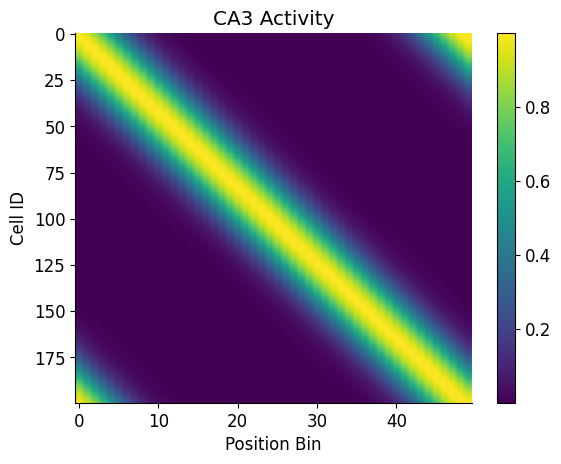

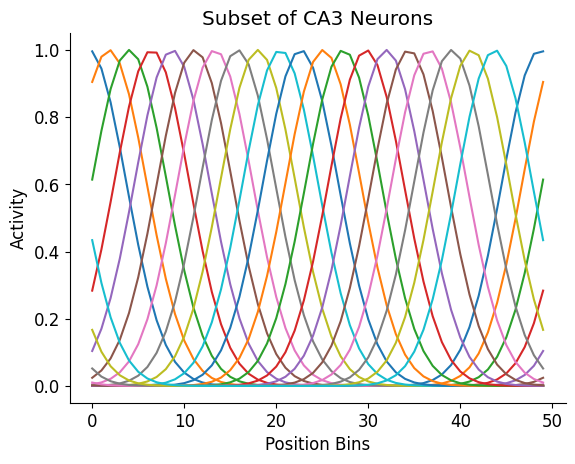

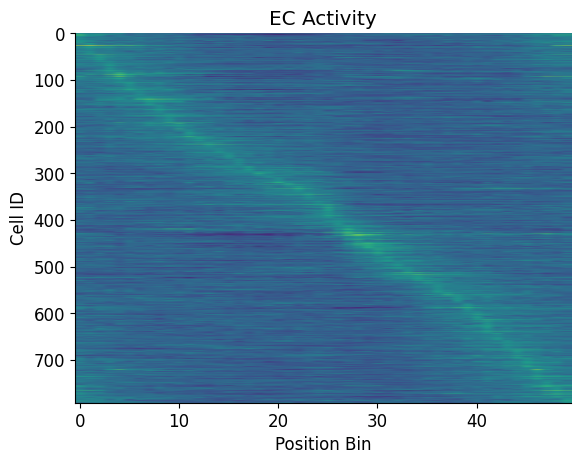

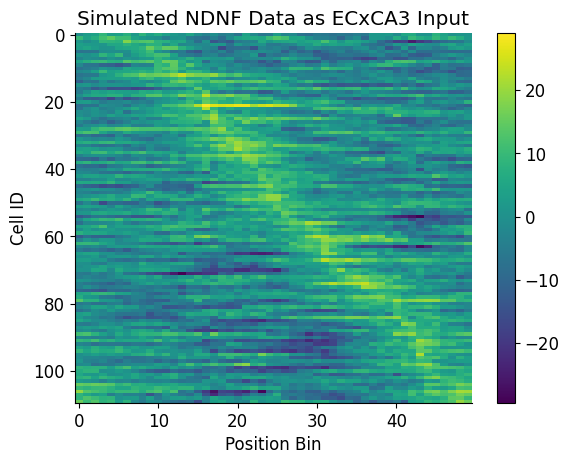

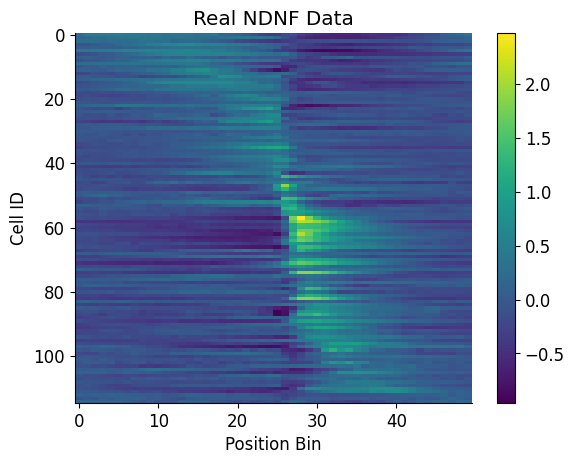

In [10]:


ca3_vs_position_all_cells_array = get_CA3_data(track_length = 180, num_cells=200)
plot_CA3(ca3_vs_position_all_cells_array)


EC_residuals_array = get_plot_EC(residual_activity_dict_EC)
    

NDNF_activity_list = get_synthetic_NDNF(EC_residuals_array, ca3_vs_position_all_cells_array, dist_type = "normal")
NDNF_activity_array = np.array(NDNF_activity_list)
sorted_NDNF_activity_array = np.argsort(np.argmax(NDNF_activity_array, axis=1))

plt.imshow(NDNF_activity_array[sorted_NDNF_activity_array, :], aspect='auto')
plt.title("Simulated NDNF Data as ECxCA3 Input")
plt.ylabel("Cell ID")
plt.xlabel("Position Bin")
plt.colorbar()
plt.show()

real_NDNF_list = []

for animal in fixed_residual_activity_dict_NDNF_newest:
    for cell in fixed_residual_activity_dict_NDNF_newest[animal]:
        real_NDNF_list.append(np.mean(fixed_residual_activity_dict_NDNF_newest[animal][cell], axis=1))
        
real_NDNF_array = np.array(real_NDNF_list)
sorted_real_NDNF_array = np.argsort(np.argmax(real_NDNF_array, axis=1))

plt.imshow(real_NDNF_array[sorted_real_NDNF_array, :], aspect='auto')
plt.title("Real NDNF Data")
plt.ylabel("Cell ID")
plt.xlabel("Position Bin")
plt.colorbar()
plt.show()



/Users/michaelfinch/CA1-interneuron-GLM/Clean_notebooks_to_date/finding_weights_over_NDNF_utils.py:260: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="Input", y="MSE", data=df, inner="box", cut=0, palette=custom_palette)


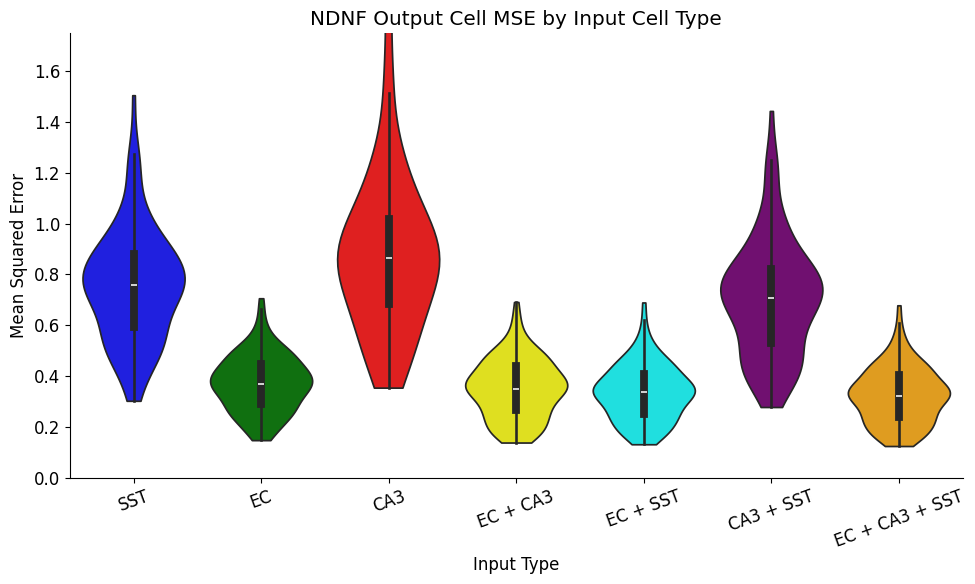

In [149]:

############### predicting NDNF where the inputs and MSE's are alll 2D trial by postion bin and therefore trial by trial variability across different mice which doesnt make sense 

#### pre flattened data arrays as input to NDNF 

EC_data_array = get_EC_data_array(residual_activity_dict_EC)
CA3_data_array = get_CA3_data_array(ca3_vs_position_all_cells_array)
SST_data_array = get_SST_data_array(activity_dict_SST, residual_activity_dict_SST)
EC_CA3_data_array = np.concatenate([EC_data_array, CA3_data_array], axis=0)
EC_CA3_data_array = np.concatenate([EC_data_array, CA3_data_array], axis=0)
EC_SST_data_array = np.concatenate([EC_data_array, SST_data_array], axis=0)
CA3_SST_data_array = np.concatenate([CA3_data_array, SST_data_array], axis=0)
EC_CA3_SST_data_array = np.concatenate([EC_data_array, CA3_data_array, SST_data_array], axis=0)

# ###### running all of the GLM's where various cell inputs try to predict NDNF output - will take some time

model_EC_just_CA3 = get_model_dict(CA3_data_array, fixed_residual_activity_dict_NDNF_newest, reg_type="ridge")
model_EC_just_SST = get_model_dict(SST_data_array, fixed_residual_activity_dict_NDNF_newest, reg_type="ridge")
model_EC_just_EC = get_model_dict(EC_data_array, fixed_residual_activity_dict_NDNF_newest, reg_type="ridge")

model_EC_EC_CA3 = get_model_dict(EC_CA3_data_array, fixed_residual_activity_dict_NDNF_newest, reg_type="ridge")
model_EC_EC_SST = get_model_dict(EC_SST_data_array, fixed_residual_activity_dict_NDNF_newest, reg_type="ridge")
model_EC_CA3_SST = get_model_dict(CA3_SST_data_array, fixed_residual_activity_dict_NDNF_newest, reg_type="ridge")
model_EC_CA3_SST = get_model_dict(CA3_SST_data_array, fixed_residual_activity_dict_NDNF_newest, reg_type="ridge")
model_EC_EC_CA3_SST = get_model_dict(EC_CA3_SST_data_array, fixed_residual_activity_dict_NDNF_newest, reg_type="ridge")

### calculating MSE of NDNF GLM prediction using other cell types as inputs vs real NDNF data  

MSE_list_just_SST, coefficients_list_just_SST = get_MSE_cell_type(model_EC_just_SST, fixed_residual_activity_dict_NDNF_newest, SST_data_array)
MSE_list_just_EC, coefficients_list_just_EC = get_MSE_cell_type(model_EC_just_EC, fixed_residual_activity_dict_NDNF_newest, EC_data_array)
MSE_list_just_CA3, coefficients_list_just_CA3 = get_MSE_cell_type(model_EC_just_CA3, fixed_residual_activity_dict_NDNF_newest, CA3_data_array)

MSE_list_EC_CA3, coefficients_list_EC_CA3 = get_MSE_cell_type(model_EC_EC_CA3, fixed_residual_activity_dict_NDNF_newest, EC_CA3_data_array)
MSE_list_EC_SST, coefficients_list_EC_SST = get_MSE_cell_type(model_EC_EC_SST, fixed_residual_activity_dict_NDNF_newest, EC_SST_data_array)
MSE_list_CA3_SST, coefficients_list_CA3_SST = get_MSE_cell_type(model_EC_CA3_SST, fixed_residual_activity_dict_NDNF_newest, CA3_SST_data_array)
MSE_list_EC_CA3_SST, coefficients_list_CA3_SST = get_MSE_cell_type(model_EC_EC_CA3_SST, fixed_residual_activity_dict_NDNF_newest, EC_CA3_SST_data_array)

inputs_list = ["SST", "EC", "CA3", "EC + CA3", "EC + SST", "CA3 + SST", "EC + CA3 + SST"]
plot_MSE_for_NDNF_pred_by_other_celltype_input(MSE_list_just_SST, MSE_list_just_EC, MSE_list_just_CA3, MSE_list_EC_CA3, MSE_list_EC_SST, MSE_list_CA3_SST, MSE_list_EC_CA3_SST, inputs_list, output_cell_type="NDNF Output")

# # ###### running all of the GLM's where various cell inputs try to predict NDNF output - will take some time


In [ ]:
######### make sure you only have positive weights off of EC
#### same thing for SST being negative weights

#### min max the data 

In [ ]:

EC_data_array = get_EC_data_array(residual_activity_dict_EC)
CA3_data_array = get_CA3_data_array(ca3_vs_position_all_cells_array)
NDNF_data_array = get_SST_data_array(fixed_activity_dict_NDNF_newest, residual_activity_dict_SST)
EC_CA3_data_array = np.concatenate([EC_data_array, CA3_data_array], axis=0)
EC_NDNF_data_array = np.concatenate([EC_data_array, NDNF_data_array], axis=0)
CA3_NDNF_data_array = np.concatenate([CA3_data_array, NDNF_data_array], axis=0)
EC_CA3_NDNF_data_array = np.concatenate([EC_data_array, CA3_data_array, NDNF_data_array], axis=0)


model_just_CA3 = get_model_dict(CA3_data_array, activity_dict_SST, reg_type="ridge")
model_just_NDNF = get_model_dict(NDNF_data_array, activity_dict_SST, reg_type="ridge")
model_just_EC = get_model_dict(EC_data_array, activity_dict_SST, reg_type="ridge")

model_EC_CA3 = get_model_dict(EC_CA3_data_array, activity_dict_SST, reg_type="ridge")
model_EC_NDNF = get_model_dict(EC_NDNF_data_array, activity_dict_SST, reg_type="ridge")
model_CA3_NDNF = get_model_dict(CA3_NDNF_data_array, activity_dict_SST, reg_type="ridge")
model_EC_CA3_NDNF = get_model_dict(EC_CA3_NDNF_data_array, activity_dict_SST, reg_type="ridge")

MSE_list_just_NDNF, coefficients_list_just_NDNF = get_MSE_cell_type(model_just_NDNF, activity_dict_SST, NDNF_data_array)
MSE_list_just_EC, coefficients_list_just_EC = get_MSE_cell_type(model_just_EC, activity_dict_SST, EC_data_array)
MSE_list_just_CA3, coefficients_list_just_CA3 = get_MSE_cell_type(model_just_CA3, activity_dict_SST, CA3_data_array)

MSE_list_EC_CA3, coefficients_list_EC_CA3 = get_MSE_cell_type(model_EC_CA3, activity_dict_SST, EC_CA3_data_array)
MSE_list_EC_NDNF, coefficients_list_EC_NDNF = get_MSE_cell_type(model_EC_NDNF, activity_dict_SST, EC_NDNF_data_array)
MSE_list_CA3_NDNF, coefficients_list_CA3_NDNF = get_MSE_cell_type(model_CA3_NDNF, activity_dict_SST, CA3_NDNF_data_array)
MSE_list_EC_CA3_NDNF, coefficients_list_CA3_NDNF = get_MSE_cell_type(model_EC_CA3_NDNF, activity_dict_SST, EC_CA3_NDNF_data_array)

inputs_list = ["NDNF", "EC", "CA3", "EC + CA3", "EC + NDNF", "CA3 + NDNF", "EC + CA3 + NDNF"]

plot_MSE_for_NDNF_pred_by_other_celltype_input(MSE_list_just_NDNF, MSE_list_just_EC, MSE_list_just_CA3, MSE_list_EC_CA3, MSE_list_EC_NDNF, MSE_list_CA3_NDNF, MSE_list_EC_CA3_NDNF, inputs_list, output_cell_type="SST Output")

In [ ]:
###### reason why ndnf input to sst output works but the reverse does not (SST input to predict NDNF output) is because the only thing we need to get a correlation is 2 cells that follow the same trend in activity might mean connectivity -- not every NDNF cell will peak at reward because not all will get 
# SST input therefore the SST input can only predict the activity of the NDNF cells that recieve SST input which is the minority --- therefore most info in the low MSE NDNF cells from SST input -- will they be the same ones that get most of the weighting when NDNF is an input 

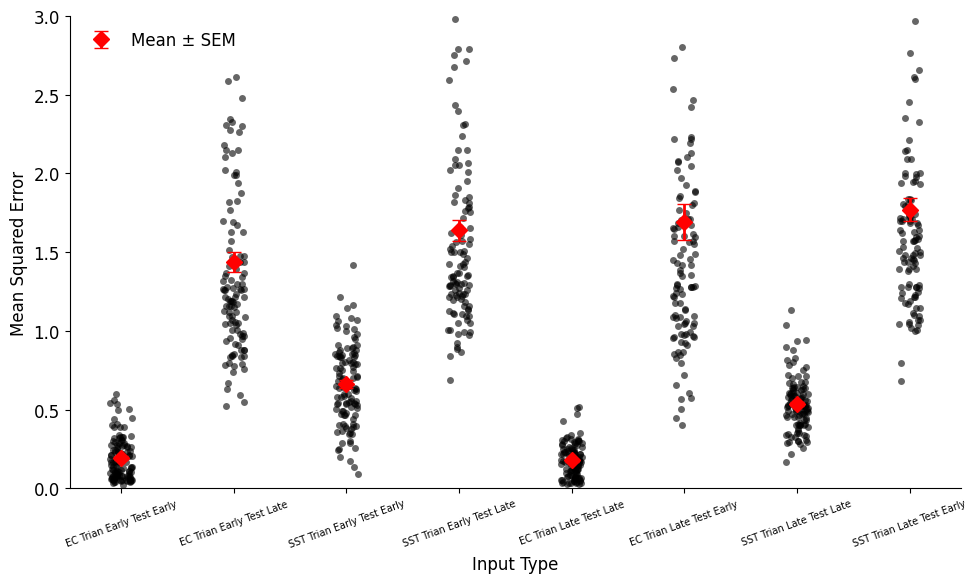

In [150]:


############# early late split for predicting NDNF 


data_early_array_EC, data_late_array_EC = get_data_array_learning_split(activity_dict_EC)
data_early_array_SST, data_late_array_SST = get_data_array_learning_split(activity_dict_SST)
data_early_array_NDNF, data_late_array_NDNF = get_data_array_learning_split(fixed_activity_dict_NDNF_newest)



##### fit the model with early trials for the whole population of EC and a single NDNF cell which will be output and get a whole model dict 
model_EC_dict_early = get_model_dict_early_celltype_late_another_celltype(data_early_array_EC, fixed_activity_dict_NDNF_newest, reg_type="ridge", early_or_late="early")

#same thing for SST 
model_SST_dict_early = get_model_dict_early_celltype_late_another_celltype(data_early_array_SST, fixed_activity_dict_NDNF_newest, reg_type="ridge", early_or_late="early")

##### take the model trained on EC and NDNF early and then get a MSE of the precition of NDNF early vs real NDNF early activity 
MSE_list_EC_early_predicting_NDNF_late, coefficients_list_EC_early = get_MSE_cell_type2(model_EC_dict_early, fixed_activity_dict_NDNF_newest, data_late_array_EC, predict_early_or_late="Late")

##### take the model trained on EC and NDNF early and then get a MSE of the precition of NDNF early vs real NDNF early activity 
MSE_list_SST_early_predicting_NDNF_late, coefficients_list_EC_early = get_MSE_cell_type2(model_SST_dict_early, fixed_activity_dict_NDNF_newest, data_late_array_SST, predict_early_or_late="Late")

MSE_list_EC_early_predicting_NDNF_early, coefficients_list_EC_early = get_MSE_cell_type2(model_EC_dict_early, fixed_activity_dict_NDNF_newest, data_early_array_EC, predict_early_or_late="early")

##### take the model trained on EC and NDNF early and then get a MSE of the precition of NDNF early vs real NDNF early activity 
MSE_list_SST_early_predicting_NDNF_early, coefficients_list_EC_early = get_MSE_cell_type2(model_SST_dict_early, fixed_activity_dict_NDNF_newest, data_early_array_SST, predict_early_or_late="early")




##### fitting to late 
model_EC_dict_late = get_model_dict_early_celltype_late_another_celltype(data_late_array_EC, fixed_activity_dict_NDNF_newest, reg_type="ridge", early_or_late="late")

# fitting to late 
model_SST_dict_late = get_model_dict_early_celltype_late_another_celltype(data_late_array_SST, fixed_activity_dict_NDNF_newest, reg_type="ridge", early_or_late="late")

### fit on late and predict late 
MSE_list_EC_late_predicting_NDNF_late, coefficients_list_EC_early = get_MSE_cell_type2(model_EC_dict_late, fixed_activity_dict_NDNF_newest, data_late_array_EC, predict_early_or_late="Late")

### fit on late and predict late
MSE_list_SST_late_predicting_NDNF_late, coefficients_list_EC_early = get_MSE_cell_type2(model_SST_dict_late, fixed_activity_dict_NDNF_newest, data_late_array_SST, predict_early_or_late="Late")



### fit on late and predict early
MSE_list_EC_late_predicting_NDNF_early, coefficients_list_EC_early = get_MSE_cell_type2(model_EC_dict_late, fixed_activity_dict_NDNF_newest, data_early_array_EC, predict_early_or_late="early")

## ### fit on late and predict early
MSE_list_SST_late_predicting_NDNF_early, coefficients_list_EC_early = get_MSE_cell_type2(model_SST_dict_late, fixed_activity_dict_NDNF_newest, data_early_array_SST, predict_early_or_late="early")


data_list = [MSE_list_EC_early_predicting_NDNF_early, MSE_list_EC_early_predicting_NDNF_late, MSE_list_SST_early_predicting_NDNF_early, MSE_list_SST_early_predicting_NDNF_late, MSE_list_EC_late_predicting_NDNF_late, MSE_list_EC_late_predicting_NDNF_early, MSE_list_SST_late_predicting_NDNF_late, MSE_list_SST_late_predicting_NDNF_early]
input_titles = ["EC Trian Early Test Early", "EC Trian Early Test Late", "SST Trian Early Test Early", "SST Trian Early Test Late", "EC Trian Late Test Late", "EC Trian Late Test Early", "SST Trian Late Test Late", "SST Trian Late Test Early"]

plot_models_trained_early_late(data_list, input_titles)



In [ ]:
##### fit the model with early trials for the whole population of EC and a single SST cell which will be output and get a whole model dict 
model_EC_dict_early_SST_output = get_model_dict_early_celltype_late_another_celltype(data_early_array_EC, activity_dict_SST, reg_type="ridge")

#same thing for SST 
model_NDNF_dict_early_SST_output = get_model_dict_early_celltype_late_another_celltype(data_early_array_SST, activity_dict_SST, reg_type="ridge")



##### take the model trained on EC and NDNF early and then get a MSE of the precition of NDNF early vs real NDNF early activity 
MSE_list_EC_early_predicting_NDNF_late, coefficients_list_EC_early = get_MSE_cell_type2(model_EC_dict_early, fixed_activity_dict_NDNF_newest, data_late_array_EC, predict_early_or_late="Late")

##### take the model trained on EC and NDNF early and then get a MSE of the precition of NDNF early vs real NDNF early activity 
MSE_list_SST_early_predicting_NDNF_late, coefficients_list_EC_early = get_MSE_cell_type2(model_SST_dict_early, fixed_activity_dict_NDNF_newest, data_late_array_SST, predict_early_or_late="Late")


MSE_list_EC_early_predicting_NDNF_early, coefficients_list_EC_early = get_MSE_cell_type2(model_EC_dict_early, fixed_activity_dict_NDNF_newest, data_early_array_EC, predict_early_or_late="early")

##### take the model trained on EC and NDNF early and then get a MSE of the precition of NDNF early vs real NDNF early activity 
MSE_list_SST_early_predicting_NDNF_early, coefficients_list_EC_early = get_MSE_cell_type2(model_SST_dict_early, fixed_activity_dict_NDNF_newest, data_early_array_SST, predict_early_or_late="early")



In [ ]:
###### analysis methodn and the question it answers 

(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50

/Users/michaelfinch/CA1-interneuron-GLM/Clean_notebooks_to_date/finding_weights_over_NDNF_utils.py:648: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="Input", y="MSE", data=df, inner="box", cut=0, palette=custom_palette)


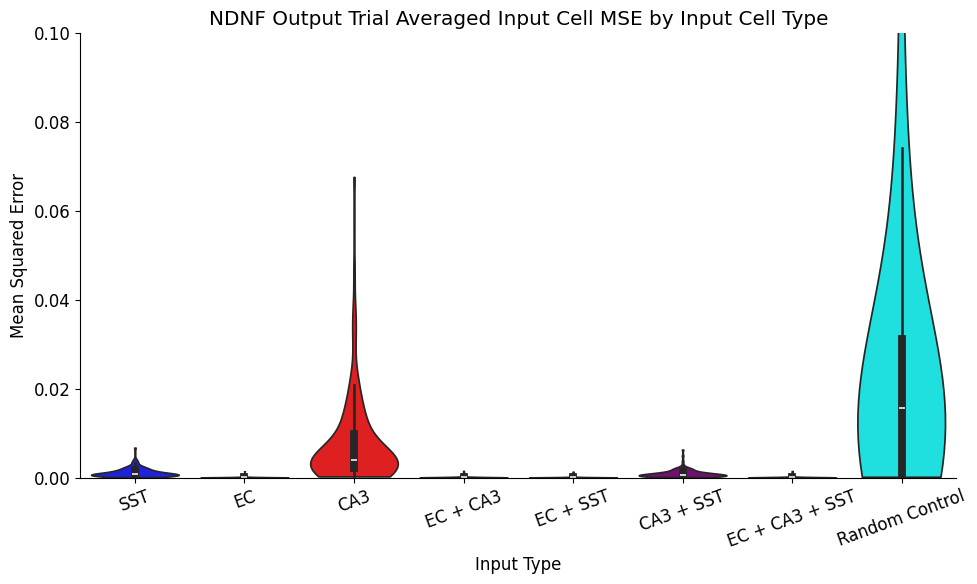

In [ ]:
######## trying it with trial averaged data 

plot_NDNF_prediction_from_other_celltypes_input_GLM(activity_dict_SST, activity_dict_EC, fixed_activity_dict_NDNF_newest, ymax=0.10)

(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50

/Users/michaelfinch/CA1-interneuron-GLM/Clean_notebooks_to_date/finding_weights_over_NDNF_utils.py:648: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="Input", y="MSE", data=df, inner="box", cut=0, palette=custom_palette)


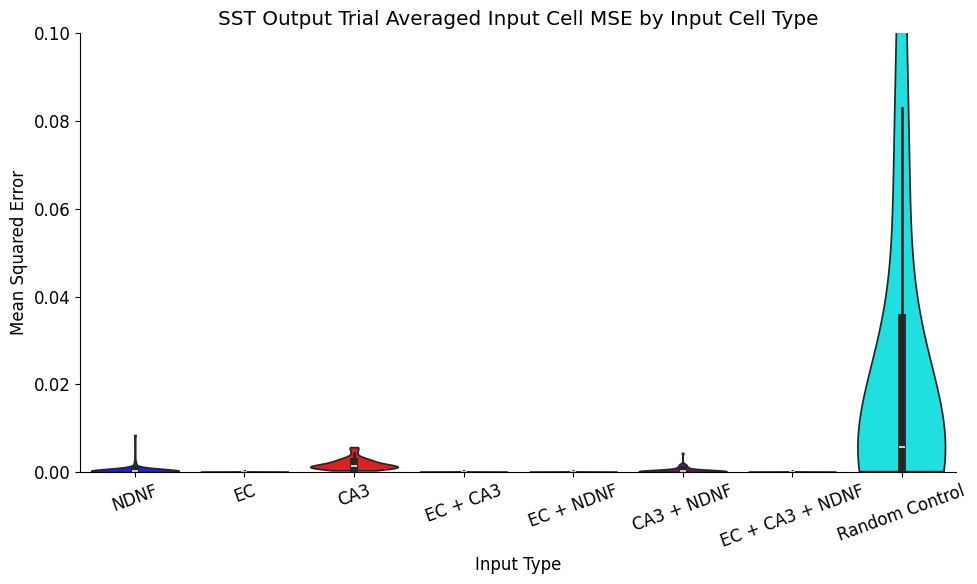

In [ ]:
######## trying it with trial averaged data 

plot_SST_prediction_from_other_celltypes_input_GLM(activity_dict_SST, activity_dict_EC, fixed_activity_dict_NDNF_newest, ymax=0.10)


In [ ]:
# def split_data_by_cp(activity_dict_EC, cp_dict_EC):
#     early_cp_dict={}
#     late_cp_dict={}

#     for idx, animal in enumerate(activity_dict_EC):
#         early_cell_cp_dict={}
#         late_cell_cp_dict={}
#         for id, cell in enumerate(activity_dict_EC[animal]):
#             data = activity_dict_EC[animal][cell]
#             cp = cp_dict_EC[idx][id]
#             early_cp = cp[0]
#             late_cp = cp[1]
#             data_early = data[:,:early_cp]
#             data_late = data[:,late_cp:]
#             early_cell_cp_dict[cell] = data_early
#             late_cell_cp_dict[cell] = data_late

#         early_cp_dict[animal] = early_cell_cp_dict
#         late_cp_dict[animal] = late_cell_cp_dict

#     return early_cp_dict, late_cp_dict



# early_cp_dict_EC, late_cp_dict_EC = split_data_by_cp(activity_dict_EC, cp_dict_EC)
# early_cp_dict_SST, late_cp_dict_SST = split_data_by_cp(activity_dict_SST, cp_dict_SST)
# early_cp_dict_NDNF, late_cp_dict_NDNF = split_data_by_cp(fixed_activity_dict_NDNF_newest, cp_dict_NDNF)




# early_cp_dict_EC, late_cp_dict_EC = split_data_by_cp(activity_dict_EC, cp_dict_EC)
# early_cp_dict_SST, late_cp_dict_SST = split_data_by_cp(activity_dict_SST, cp_dict_SST)
# early_cp_dict_NDNF, late_cp_dict_NDNF = split_data_by_cp(fixed_activity_dict_NDNF_newest, cp_dict_NDNF)

# early_cp_dicts = [early_cp_dict_EC, early_cp_dict_SST, early_cp_dict_NDNF]
# late_cp_dicts = [late_cp_dict_EC, late_cp_dict_SST, late_cp_dict_NDNF]


Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 5 cells
    Animal 1: 15 cells
    Animal 2: 6 cells
    Animal 3: 4 cells
    Animal 4: 13 cells
    Animal 5: 13 cells
    Animal 6: 3 cells
    Animal 7: 3 cells
    Animal 8: 3 cells
    Animal 9: 10 cells
Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 192 cells
    Animal 1: 150 cells
    Animal 2: 154 cells
    Animal 3: 82 cells
    Animal 4: 74 cells
    Animal 5: 64 cells
    Animal 6: 76 cells
Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 12 cells
    Animal 1: 16 cells
    Animal 2: 4 cells
    Animal 3: 10 cells
    Animal 4: 8 cells
    Animal 5: 7 cells
    Animal 6: 11 cells
    Animal 7: 10 cells
    Animal 8: 17 cells
    Animal 9: 17 cells
    Animal 10: 9 cells
    Animal 11: 6 cells
    Animal 12: 10 cells
    Animal 13: 9 cells
    Animal 14: 6 cells
    Animal 15: 12 cells
    Animal 16: 7 cells
    Animal 17: 7 cells
    Animal 18: 7 cells
    Animal 19: 10 cells
    Animal 20: 9 cells
    Animal 21: 

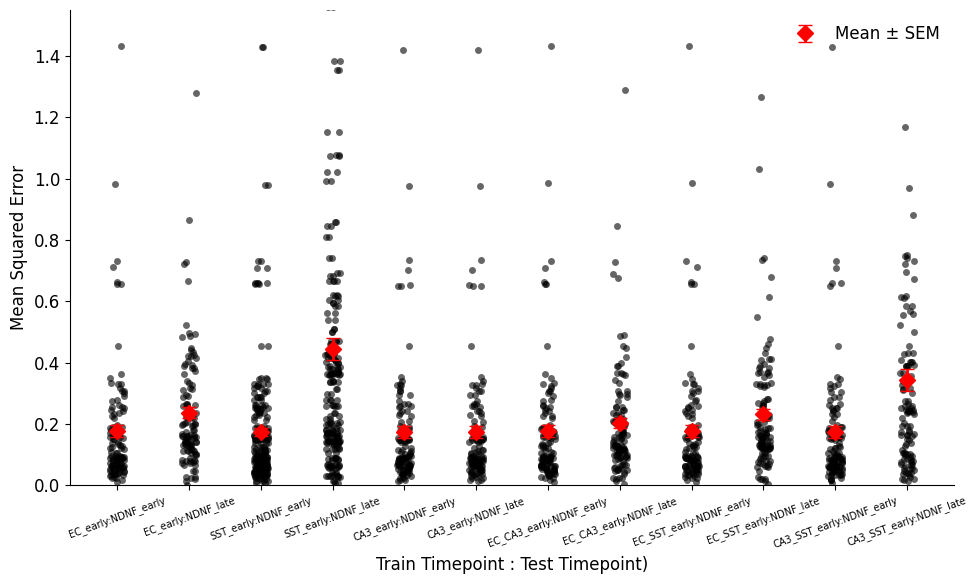

In [86]:


##################### the worst models are the ones trained on early but are predicting late -- suggests NDNF learns alot 




##### getting the early data 

#### load the cutpoint data 

mse_dir = "/Users/michaelfinch/CA1-interneuron-GLM/datasets/cell_SST_model_ranks20_contig_x00_cells"
cell_SST_model_ranks20_contig_x00 = get_model_data_per_cell(mse_dir)

mse_dir = "/Users/michaelfinch/CA1-interneuron-GLM/datasets/cell_EC_model_ranks20_contig_x00_cells"
cell_EC_model_ranks20_contig_x00 = get_model_data_per_cell(mse_dir)

mse_dir = "/Users/michaelfinch/CA1-interneuron-GLM/datasets/real_final_NDNF_model_ranks20_contig_x00_cell"
cell_NDNF_model_ranks20_contig_x00 = get_model_data_per_cell(mse_dir)


fixed_model_dict_NDNF_newest = get_fixed_model_dict_NDNF_newest(cell_NDNF_model_ranks20_contig_x00)



cp_dict_EC = get_cp_dict(cell_EC_model_ranks20_contig_x00)
cp_dict_NDNF = get_cp_dict(fixed_model_dict_NDNF_newest)
cp_dict_SST = get_cp_dict(cell_SST_model_ranks20_contig_x00)




plot_early_late_split_all_input_types(activity_dict_SST, activity_dict_EC, fixed_activity_dict_NDNF_newest, ca3_vs_position_all_cells_array, cp_dict_EC, cp_dict_SST, cp_dict_NDNF, ymax=1.55)



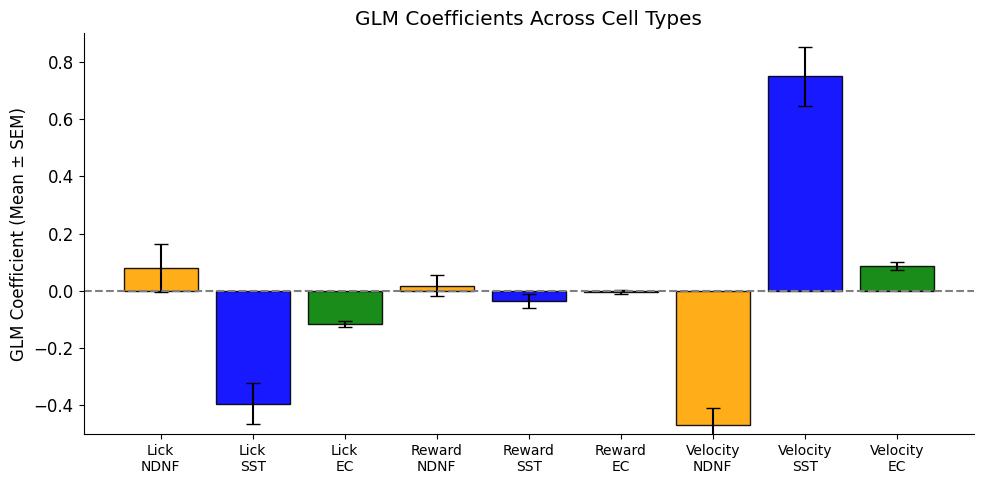

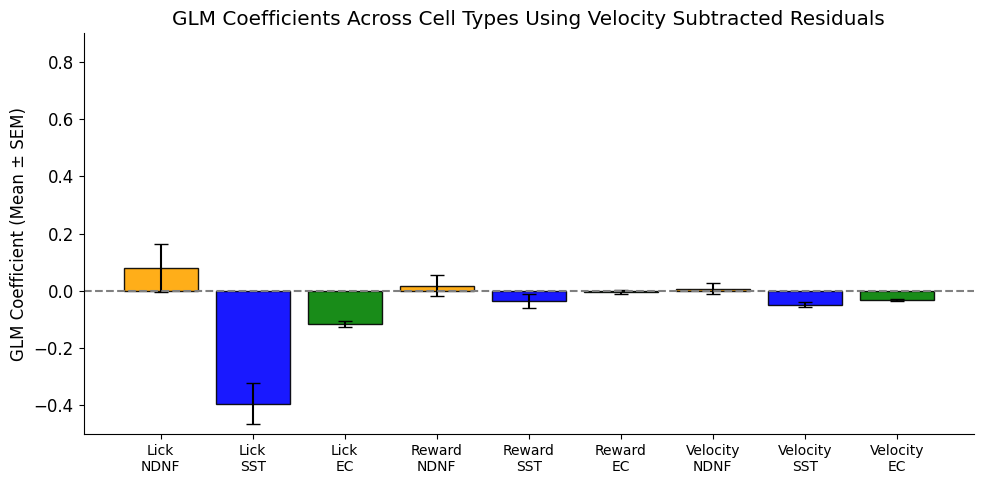

In [4]:


########################### gets you the coefficients of all the cell types together 

from sklearn.linear_model import LinearRegression


EC_GLM_models, design_matrix_dict_EC = get_GLM_models_cell_type(activity_dict_EC, factors_dict_EC)
SST_GLM_models, design_matrix_dict_SST = get_GLM_models_cell_type(activity_dict_SST, factors_dict_SST)
NDNF_GLM_models, design_matrix_dict_NDNF = get_GLM_models_cell_type(fixed_activity_dict_NDNF_newest, fixed_factors_dict_NDNF_newest)
    

###### 
indices_array = np.arange(3)
MSE_list_EC, prediction_list_EC, weights_list_EC = remove_behaviors_GLM(activity_dict_EC, EC_GLM_models, design_matrix_dict_EC, indices_array)

indices_array = np.arange(3)
MSE_list_NDNF, prediction_list_NDNF, weights_list_NDNF = remove_behaviors_GLM(fixed_activity_dict_NDNF_newest, NDNF_GLM_models, design_matrix_dict_NDNF, indices_array)

indices_array = np.arange(3)
MSE_list_SST, prediction_list_SST, weights_list_SST = remove_behaviors_GLM(activity_dict_SST, SST_GLM_models, design_matrix_dict_SST, indices_array)



plot_coefficients_all_celltypes_together(weights_list_NDNF, weights_list_SST, weights_list_EC, title="GLM Coefficients Across Cell Types")



EC_GLM_models_r, design_matrix_dict_EC_r = get_GLM_models_cell_type(residual_activity_dict_EC, factors_dict_EC)
SST_GLM_models_r, design_matrix_dict_SST_r = get_GLM_models_cell_type(residual_activity_dict_SST, factors_dict_SST)
NDNF_GLM_models_r, design_matrix_dict_NDNF_r = get_GLM_models_cell_type(fixed_residual_activity_dict_NDNF_newest, fixed_factors_dict_NDNF_newest)
    

###### 
indices_array = np.arange(3)
MSE_list_EC, prediction_list_EC, weights_list_EC_r = remove_behaviors_GLM(activity_dict_EC, EC_GLM_models_r, design_matrix_dict_EC_r, indices_array)

indices_array = np.arange(3)
MSE_list_NDNF, prediction_list_NDNF, weights_list_NDNF_r = remove_behaviors_GLM(fixed_activity_dict_NDNF_newest, NDNF_GLM_models_r, design_matrix_dict_NDNF_r, indices_array)

indices_array = np.arange(3)
MSE_list_SST, prediction_list_SST, weights_list_SST_r = remove_behaviors_GLM(activity_dict_SST, SST_GLM_models_r, design_matrix_dict_SST_r, indices_array)



plot_coefficients_all_celltypes_together(weights_list_NDNF_r, weights_list_SST_r, weights_list_EC_r, title="GLM Coefficients Across Cell Types Using Velocity Subtracted Residuals")


# plot_coefficients_cell_type(weights_list_EC, cell_type="EC")
# plot_coefficients_cell_type(weights_list_NDNF, cell_type="NDNF")
# plot_coefficients_cell_type(weights_list_SST, cell_type="SST")





In [11]:

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score

def get_factor_array(fixed_factors_dict_NDNF_newest, n_trials, vars='Licks'):
    lick_list = []
    for animal in fixed_factors_dict_NDNF_newest:
        lick_list.append(fixed_factors_dict_NDNF_newest[animal][vars][:,:n_trials])

    lick_array = np.array(lick_list)
    return lick_array

def setup_log_reg(fixed_activity_dict_NDNF_newest, fixed_factors_dict_NDNF_newest):  
    
    shape_list =[]
    for animal in fixed_factors_dict_NDNF_newest:
        shape_list.append(fixed_factors_dict_NDNF_newest[animal]['Licks'].shape[1])

    n_trials = np.min(shape_list)

    EC = {}
    for idx, animal in enumerate(fixed_activity_dict_NDNF_newest):
        NDNF_list = []
        for cell in fixed_activity_dict_NDNF_newest[animal]:
            NDNF_list.append(fixed_activity_dict_NDNF_newest[animal][cell][:,:n_trials])

        NDNF_array = np.array(NDNF_list)
        EC[idx] = NDNF_array

    NDNF_activity_array = np.array(NDNF_list)


    lick_array = get_factor_array(fixed_factors_dict_NDNF_newest, n_trials, vars='Licks')
    reward_array = get_factor_array(fixed_factors_dict_NDNF_newest, n_trials, vars='Reward_loc')
    velocity_array = get_factor_array(fixed_factors_dict_NDNF_newest, n_trials, vars='Velocity')

    return EC, lick_array, reward_array, velocity_array


def fit_log_reg(X, y, n_splits=5):

    """
    X: is a dict of animals where every vaule is shape (cells, trials, pos) for that animal 
    y: shape (trials, pos) for the same animal 
    """

    log_reg_animal_dict = {}


    for animal in X:
        animal_data = X[animal]
        variable_data = y[animal,:,:]
        n_cells, n_trials, n_pos = animal_data.shape
        X_reshaped = animal_data.transpose(1, 2, 0).reshape(n_trials * n_pos, n_cells)
        y_flat = variable_data.flatten()

        all_probs = np.zeros(n_trials * n_pos)
        all_preds = np.zeros(n_trials * n_pos)

        kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
        
        accuracies = []
        preds = []
        probs = []

        for train_index, test_index in kf.split(X_reshaped):
            X_train, X_test = X_reshaped[train_index], X_reshaped[test_index]
            y_train, y_test = y_flat[train_index], y_flat[test_index]

            model = LogisticRegression(max_iter=1000)
            model.fit(X_train, y_train)

            y_pred = model.predict(X_test)
            y_prob = model.predict_proba(X_test)[:, 1]
            all_probs[test_index] = y_prob 
            all_preds[test_index] = y_pred

            accuracies.append(accuracy_score(y_test, y_pred))
            preds.append(y_pred)
            probs.append(y_prob)

        all_probs_reshaped = all_probs.reshape(n_trials, n_pos)
        all_preds_reshaped = all_preds.reshape(n_trials, n_pos)
        y_true_reshaped = y_flat.reshape(n_trials, n_pos)

        log_reg_animal_dict[animal] = {"accuracies":accuracies,
        "all_preds_reshaped": all_preds_reshaped,
        "all_probs_reshaped": all_probs_reshaped,
        "y_true_reshaped":y_true_reshaped
        }

    return log_reg_animal_dict


def get_GLM_models_cell_type(fixed_activity_dict_NDNF_newest, fixed_factors_dict_NDNF_newest):
    NDNF_GLM_models = {}
    design_matrix_dict={}

    for i, animal in enumerate(fixed_activity_dict_NDNF_newest):
        GLM_cell_models = {}
        design_matrix_cell_dict = {}
        for cell in fixed_activity_dict_NDNF_newest[animal]:
            animal_lick_data = fixed_factors_dict_NDNF_newest[animal]['Licks']
            animal_lick_data_flat = animal_lick_data.flatten()

            animal_reward_data = fixed_factors_dict_NDNF_newest[animal]['Reward_loc']
            animal_reward_data_flat = animal_reward_data.flatten()

            animal_velocity_data = fixed_factors_dict_NDNF_newest[animal]['Velocity']
            animal_velocity_data_flat = animal_velocity_data.flatten()

            design_matrix = np.vstack([animal_lick_data_flat, animal_reward_data_flat, animal_velocity_data_flat])
            design_matrix_cell_dict[cell] = design_matrix
            
            neuron_activity = fixed_activity_dict_NDNF_newest[animal][cell]

            neuron_activity_flat = neuron_activity.flatten()

            model = fit_GLM2(design_matrix, neuron_activity_flat, regression='linear', alphas=None)
            
            GLM_cell_models[cell] = model

        NDNF_GLM_models[animal] = GLM_cell_models
        design_matrix_dict[animal] = design_matrix_cell_dict

    return NDNF_GLM_models, design_matrix_dict




EC_GLM_models, design_matrix_dict_EC = get_GLM_models_cell_type(activity_dict_EC, factors_dict_EC)
SST_GLM_models, design_matrix_dict_SST = get_GLM_models_cell_type(activity_dict_SST, factors_dict_SST)
NDNF_GLM_models, design_matrix_dict_NDNF = get_GLM_models_cell_type(fixed_activity_dict_NDNF_newest, fixed_factors_dict_NDNF_newest)


    

#####LRV

###### 
indices_array = np.arange(3)
MSE_list_EC, prediction_list_EC, weights_list_EC = remove_behaviors_GLM(activity_dict_EC, EC_GLM_models, design_matrix_dict_EC, indices_array)

MSE_list_NDNF, prediction_list_NDNF, weights_list_NDNF = remove_behaviors_GLM(fixed_activity_dict_NDNF_newest, NDNF_GLM_models, design_matrix_dict_NDNF, indices_array)

MSE_list_SST, prediction_list_SST, weights_list_SST = remove_behaviors_GLM(activity_dict_SST, SST_GLM_models, design_matrix_dict_SST, indices_array)



NDNF_dict, NDNF_lick_array, NDNF_reward_array, NDNF_velocity_array = setup_log_reg(fixed_activity_dict_NDNF_newest, fixed_factors_dict_NDNF_newest)
SST_dict, SST_lick_array, SST_reward_array, SST_velocity_array = setup_log_reg(activity_dict_SST, factors_dict_SST)
EC_dict, EC_lick_array, EC_reward_array, EC_velocity_array = setup_log_reg(activity_dict_EC, factors_dict_EC)

NDNF_residual_dict, NDNF_lick_array, NDNF_reward_array, NDNF_velocity_array = setup_log_reg(fixed_residual_activity_dict_NDNF_newest, fixed_factors_dict_NDNF_newest)
SST_residual_dict, SST_lick_array, SST_reward_array, SST_velocity_array = setup_log_reg(residual_activity_dict_SST, factors_dict_SST)
EC_residual_dict, EC_lick_array, EC_reward_array, EC_velocity_array = setup_log_reg(residual_activity_dict_EC, factors_dict_EC)


lick_binarized_NDNF  = (NDNF_lick_array>0).astype(int)
log_reg_animal_dict_NDNF_lick = fit_log_reg(NDNF_dict, lick_binarized_NDNF, n_splits=5)
log_reg_animal_dict_NDNF_lick_res = fit_log_reg(NDNF_residual_dict, lick_binarized_NDNF, n_splits=5)

lick_binarized_SST  = (SST_lick_array>0).astype(int)
log_reg_animal_dict_SST_lick = fit_log_reg(SST_dict, lick_binarized_SST, n_splits=5)
log_reg_animal_dict_SST_lick_res = fit_log_reg(SST_residual_dict, lick_binarized_SST, n_splits=5)

lick_binarized_EC  = (EC_lick_array>0).astype(int)
log_reg_animal_dict_EC_lick = fit_log_reg(EC_dict, lick_binarized_EC, n_splits=5)
log_reg_animal_dict_EC_lick_res = fit_log_reg(EC_residual_dict, lick_binarized_EC, n_splits=5)




In [33]:



EC_GLM_models, design_matrix_dict_EC = get_GLM_models_cell_type(activity_dict_EC, factors_dict_EC)
SST_GLM_models, design_matrix_dict_SST = get_GLM_models_cell_type(activity_dict_SST, factors_dict_SST)
NDNF_GLM_models, design_matrix_dict_NDNF = get_GLM_models_cell_type(fixed_activity_dict_NDNF_newest, fixed_factors_dict_NDNF_newest)


    


def remove_behaviors_GLM(activity_dict_NDNF, NDNF_GLM_models, design_matrix_dict_NDNF, indices_array):
  MSE_list = []
  prediction_list = []
  weights_list = []

  for animal in NDNF_GLM_models:
    for cell in NDNF_GLM_models[animal]:
    
        neuron_data = activity_dict_NDNF[animal][cell]
        weights = NDNF_GLM_models[animal][cell].coef_
        intercept = NDNF_GLM_models[animal][cell].intercept_

        behavioral_correlates_before_slice = design_matrix_dict_NDNF[animal][cell][indices_array,:]

        prediction = (weights[indices_array] @ behavioral_correlates_before_slice) + intercept
        prediction_reshaped = prediction.reshape(neuron_data.shape)
        prediction_list.append(prediction_reshaped)

        mean_neuron_data = np.mean(neuron_data, axis=1)
        mean_prediction_data = np.mean(prediction_reshaped, axis=1)

        MSE = np.mean(np.square(mean_neuron_data - mean_prediction_data))
        MSE_list.append(MSE)

        weights_list.append(weights)

  return MSE_list, prediction_list, weights_list


#####LRV

###### 
indices_array = np.arange(3)
MSE_list_EC, prediction_list_EC, weights_list_EC = remove_behaviors_GLM(activity_dict_EC, EC_GLM_models, design_matrix_dict_EC, indices_array)

MSE_list_NDNF, prediction_list_NDNF, weights_list_NDNF = remove_behaviors_GLM(fixed_activity_dict_NDNF_newest, NDNF_GLM_models, design_matrix_dict_NDNF, indices_array)

MSE_list_SST, prediction_list_SST, weights_list_SST = remove_behaviors_GLM(activity_dict_SST, SST_GLM_models, design_matrix_dict_SST, indices_array)




###### 
indices_array_L = [0]
MSE_list_EC_L, prediction_list_EC_L, weights_list_EC_L = remove_behaviors_GLM(activity_dict_EC, EC_GLM_models, design_matrix_dict_EC, indices_array_L)

MSE_list_NDNF_L, prediction_list_NDNF_L, weights_list_NDNF_L = remove_behaviors_GLM(fixed_activity_dict_NDNF_newest, NDNF_GLM_models, design_matrix_dict_NDNF, indices_array_L)

MSE_list_SST_L, prediction_list_SST_L, weights_list_SST_L = remove_behaviors_GLM(activity_dict_SST, SST_GLM_models, design_matrix_dict_SST, indices_array_L)


indices_array_R = [1]
MSE_list_EC_R, prediction_list_EC_R, weights_list_EC_R = remove_behaviors_GLM(activity_dict_EC, EC_GLM_models, design_matrix_dict_EC, indices_array_R)

MSE_list_NDNF_R, prediction_list_NDNF_R, weights_list_NDNF_R = remove_behaviors_GLM(fixed_activity_dict_NDNF_newest, NDNF_GLM_models, design_matrix_dict_NDNF, indices_array_R)

MSE_list_SST_R, prediction_list_SST_R, weights_list_SST_R = remove_behaviors_GLM(activity_dict_SST, SST_GLM_models, design_matrix_dict_SST, indices_array_R)


indices_array_V = [2]
MSE_list_EC_V, prediction_list_EC_V, weights_list_EC_V = remove_behaviors_GLM(activity_dict_EC, EC_GLM_models, design_matrix_dict_EC, indices_array_V)

MSE_list_NDNF_V, prediction_list_NDNF_V, weights_list_NDNF_V = remove_behaviors_GLM(fixed_activity_dict_NDNF_newest, NDNF_GLM_models, design_matrix_dict_NDNF, indices_array_V)

MSE_list_SST_V, prediction_list_SST_V, weights_list_SST_V = remove_behaviors_GLM(activity_dict_SST, SST_GLM_models, design_matrix_dict_SST, indices_array_V)










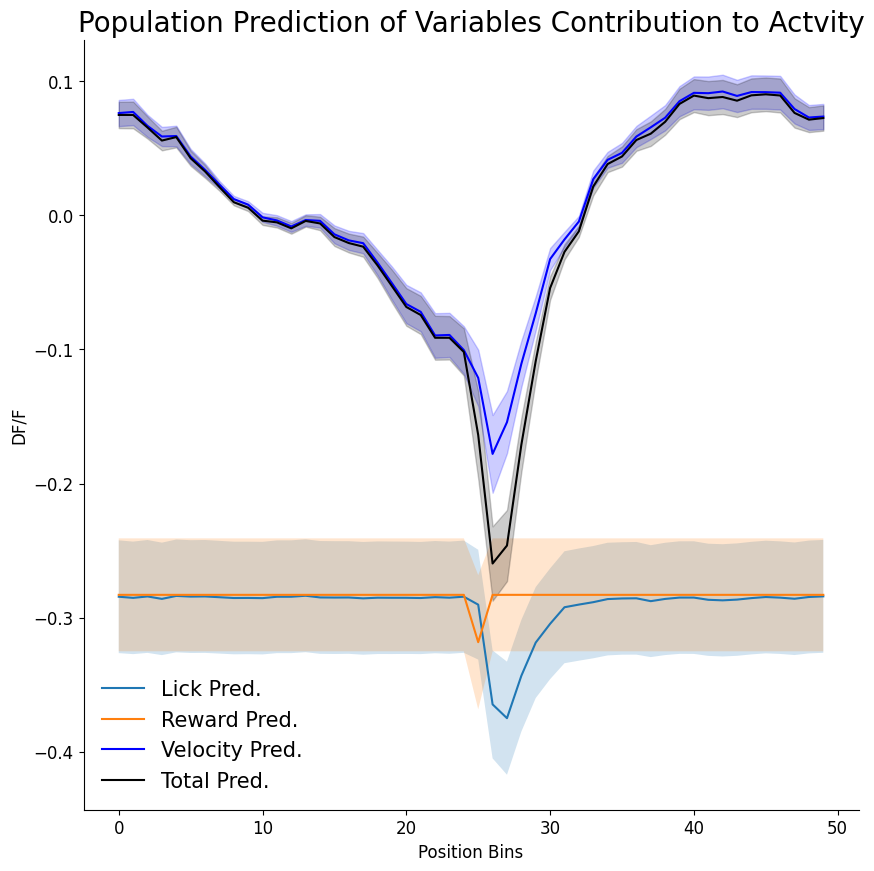

In [51]:
def get_mean_array(prediction_list_SST_L):
    mean_prediction_list_SST_L = []
    for i in range(len(prediction_list_SST_L)):
        mean_prediction_list_SST_L.append(np.mean(prediction_list_SST_L[i], axis=1))
    return mean_prediction_list_SST_L

mean_prediction_list_SST_L = get_mean_array(prediction_list_SST_L)
mean_prediction_list_SST_R = get_mean_array(prediction_list_SST_R)
mean_prediction_list_SST_V = get_mean_array(prediction_list_SST_V)
mean_prediction_list_SST = get_mean_array(prediction_list_SST)

prediction_array_SST_L = np.array(mean_prediction_list_SST_L)
prediction_array_SST_R = np.array(mean_prediction_list_SST_R)
prediction_array_SST_V = np.array(mean_prediction_list_SST_V)
prediction_array_SST = np.array(mean_prediction_list_SST)


mean_prediction_array_SST_L = np.mean(prediction_array_SST_L, axis=0)
sem_prediction_array_SST_L = sem(prediction_array_SST_L, axis=0)
mean_prediction_array_SST_R = np.mean(prediction_array_SST_R, axis=0)
sem_prediction_array_SST_R = sem(prediction_array_SST_R, axis=0)
mean_prediction_array_SST_V = np.mean(prediction_array_SST_V, axis=0)
sem_prediction_array_SST_V = sem(prediction_array_SST_V, axis=0)
mean_prediction_array_SST = np.mean(prediction_array_SST, axis=0)
sem_prediction_array_SST = sem(prediction_array_SST, axis=0)

SST_list = []
for animal in activity_dict_SST:
    for cell in activity_dict_SST[animal]:
        SST_list.append(np.mean(activity_dict_SST[animal][cell], axis=1))

sst_array = np.array(SST_list)

mean_real = np.mean(sst_array, axis=0)
sem_real = sem(sst_array, axis=0)

plt.figure(figsize=(10, 10))
plt.plot(mean_prediction_array_SST_L, label="Lick Pred.")
plt.fill_between(range(len(mean_prediction_array_SST_L)), mean_prediction_array_SST_L+sem_prediction_array_SST_L, mean_prediction_array_SST_L-sem_prediction_array_SST_L, alpha=0.2)
plt.plot(mean_prediction_array_SST_R, label="Reward Pred.")
plt.fill_between(range(len(mean_prediction_array_SST_R)), mean_prediction_array_SST_R+sem_prediction_array_SST_R, mean_prediction_array_SST_R-sem_prediction_array_SST_R, alpha=0.2)
plt.plot(mean_prediction_array_SST_V, label="Velocity Pred.", color='b')
plt.fill_between(range(len(mean_prediction_array_SST_V)), mean_prediction_array_SST_V+sem_prediction_array_SST_V, mean_prediction_array_SST_V-sem_prediction_array_SST_V, alpha=0.2, color='b')
plt.plot(mean_prediction_array_SST, label="Total Pred.", color='k')
plt.fill_between(range(len(mean_prediction_array_SST)), mean_prediction_array_SST+sem_prediction_array_SST, mean_prediction_array_SST-sem_prediction_array_SST, alpha=0.2, color='k')
# plt.plot(mean_real, label="Raw Activity", color='k')
# plt.fill_between(range(len(mean_real)), mean_real+sem_real, mean_real-sem_real, alpha=0.2, color='k')
plt.title("Population Prediction of Variables Contribution to Actvity", fontsize=20)
plt.xlabel("Position Bins")
plt.ylabel("DF/F")
plt.legend(fontsize=15)
plt.show()

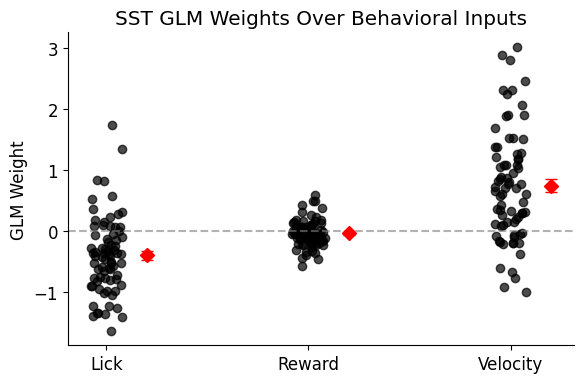

In [47]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import sem

# Assuming weights_list_SST is already defined
lick_weights = []
reward_weights = []
velocity_weights = []

for data in weights_list_SST:
    lick_weights.append(data[0])
    reward_weights.append(data[1])
    velocity_weights.append(data[2])

# Convert to numpy arrays
lick_weights = np.array(lick_weights)
reward_weights = np.array(reward_weights)
velocity_weights = np.array(velocity_weights)

# X positions and labels
x_labels = ['Lick', 'Reward', 'Velocity']
x_pos = np.arange(len(x_labels))  # [0, 1, 2]
x_offset = 0.2  # Offset for mean+SEM
jitter_strength = 0.08

# Create figure
plt.figure(figsize=(6, 4))

# Plot black dots with jitter
np.random.seed(0)  # for reproducibility
for i, weights in enumerate([lick_weights, reward_weights, velocity_weights]):
    jitter = np.random.uniform(-jitter_strength, jitter_strength, size=len(weights))
    plt.scatter(np.full_like(weights, x_pos[i]) + jitter, weights, color='black', alpha=0.7)

# Plot diamond + SEM
for i, weights in enumerate([lick_weights, reward_weights, velocity_weights]):
    mean_val = np.mean(weights)
    sem_val = sem(weights)
    plt.errorbar(x_pos[i] + x_offset, mean_val, yerr=sem_val,
                 fmt='D', color='red', capsize=4, markersize=7, label='_nolegend_')

# Formatting
plt.xticks(x_pos, x_labels)
plt.ylabel("GLM Weight")
plt.title("SST GLM Weights Over Behavioral Inputs")
plt.axhline(0, color='grey', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


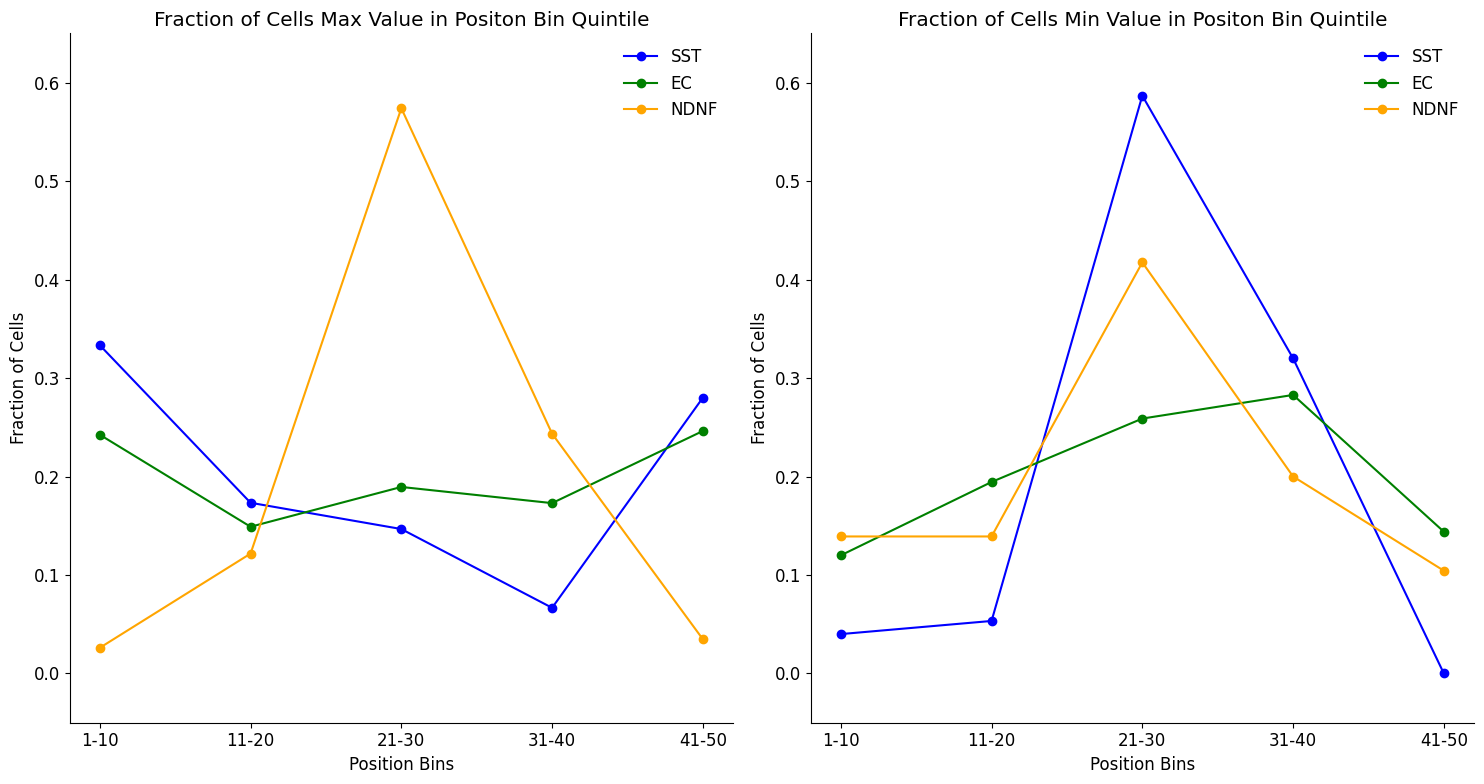

In [94]:

def get_argmin_argmax_data_binned(activity_dict_SST, cp_dict_SST, use_argmax=True, split_early_late=False, use_early=True):

    """
    params animal_average_selectivity_dict_SST_r: selectivity value for every cell in a dict
    returns binned_data: the cells with selectiivty values that fit within each bin (percent of data)
    """

    count_0_10 = 0
    count_10_20 = 0
    count_20_30 = 0
    count_30_40 = 0
    count_40_50 = 0

    tot_cells = 0

    for idx, animal in enumerate(activity_dict_SST):
        for idt, cell in enumerate(activity_dict_SST[animal]):
            data = activity_dict_SST[animal][cell]
            if split_early_late:
                cp = cp_dict_SST[idx][idt]
                e_cut = cp[0]
                l_cut = cp[1]
                if use_argmax:
                    if use_early:
                        SST_argmax = np.argmax(np.mean(data[:,:e_cut], axis=1))
                    else:
                        SST_argmax = np.argmax(np.mean(data[:,-l_cut:], axis=1))

                else:
                    if use_early:
                        SST_argmax = np.argmin(np.mean(data[:,:e_cut], axis=1))
                    else:
                        SST_argmax = np.argmin(np.mean(data[:,-l_cut:], axis=1))

            else:
                if use_argmax:
                    SST_argmax = np.argmax(np.mean(data, axis=1))
                else:
                    SST_argmax = np.argmin(np.mean(data, axis=1))

            if SST_argmax <=9:
                count_0_10+=1
            elif 9 < SST_argmax <=19:
                count_10_20+=1
            elif 19 < SST_argmax <=29:
                count_20_30+=1
            elif 29 < SST_argmax <=39:
                count_30_40+=1
            elif 39 < SST_argmax <=49:
                count_40_50+=1
            tot_cells+=1

    counts_array = np.array([count_0_10/tot_cells, count_10_20/tot_cells, count_20_30/tot_cells, count_30_40/tot_cells, count_40_50/tot_cells])
    return counts_array

binned_data_SST_argmax = get_argmin_argmax_data_binned(residual_activity_dict_SST, cp_dict_SST, use_argmax=True, split_early_late=False, use_early=True)
binned_data_SST_argmin= get_argmin_argmax_data_binned(residual_activity_dict_SST, cp_dict_SST, use_argmax=False, split_early_late=False, use_early=True)

binned_data_EC_argmax = get_argmin_argmax_data_binned(residual_activity_dict_EC, cp_dict_EC, use_argmax=True, split_early_late=False, use_early=True)
binned_data_EC_argmin= get_argmin_argmax_data_binned(residual_activity_dict_EC, cp_dict_EC, use_argmax=False, split_early_late=False, use_early=True)

binned_data_NDNF_argmax = get_argmin_argmax_data_binned(fixed_residual_activity_dict_NDNF_newest, cp_dict_NDNF, use_argmax=True, split_early_late=False, use_early=True)
binned_data_NDNF_argmin= get_argmin_argmax_data_binned(fixed_residual_activity_dict_NDNF_newest, cp_dict_NDNF, use_argmax=False, split_early_late=False, use_early=True)

fig, axs = plt.subplots(1,2, figsize=(15,8))
axs[0].plot(binned_data_SST_argmax, color='b', label="SST", marker="o")
axs[0].plot(binned_data_EC_argmax, color='green', label="EC", marker="o")
axs[0].plot(binned_data_NDNF_argmax, color='orange', label="NDNF", marker="o")
axs[0].set_ylabel("Fraction of Cells")
axs[0].set_xlabel("Position Bins")
axs[0].set_xticks(np.arange(5), ["1-10","11-20","21-30","31-40","41-50"])
axs[0].set_title("Fraction of Cells Max Value in Positon Bin Quintile")
axs[0].set_ylim(-0.05,0.65)
axs[0].legend()

axs[1].plot(binned_data_SST_argmin, color='b', label="SST", marker="o")
axs[1].plot(binned_data_EC_argmin, color='green', label="EC", marker="o")
axs[1].plot(binned_data_NDNF_argmin, color='orange', label="NDNF", marker="o")
axs[1].set_ylabel("Fraction of Cells")
axs[1].set_xlabel("Position Bins")
axs[1].set_xticks(np.arange(5), ["1-10","11-20","21-30","31-40","41-50"])
axs[1].set_title("Fraction of Cells Min Value in Positon Bin Quintile")
axs[1].set_ylim(-0.05,0.65)
axs[1].legend()

plt.tight_layout()
plt.show()



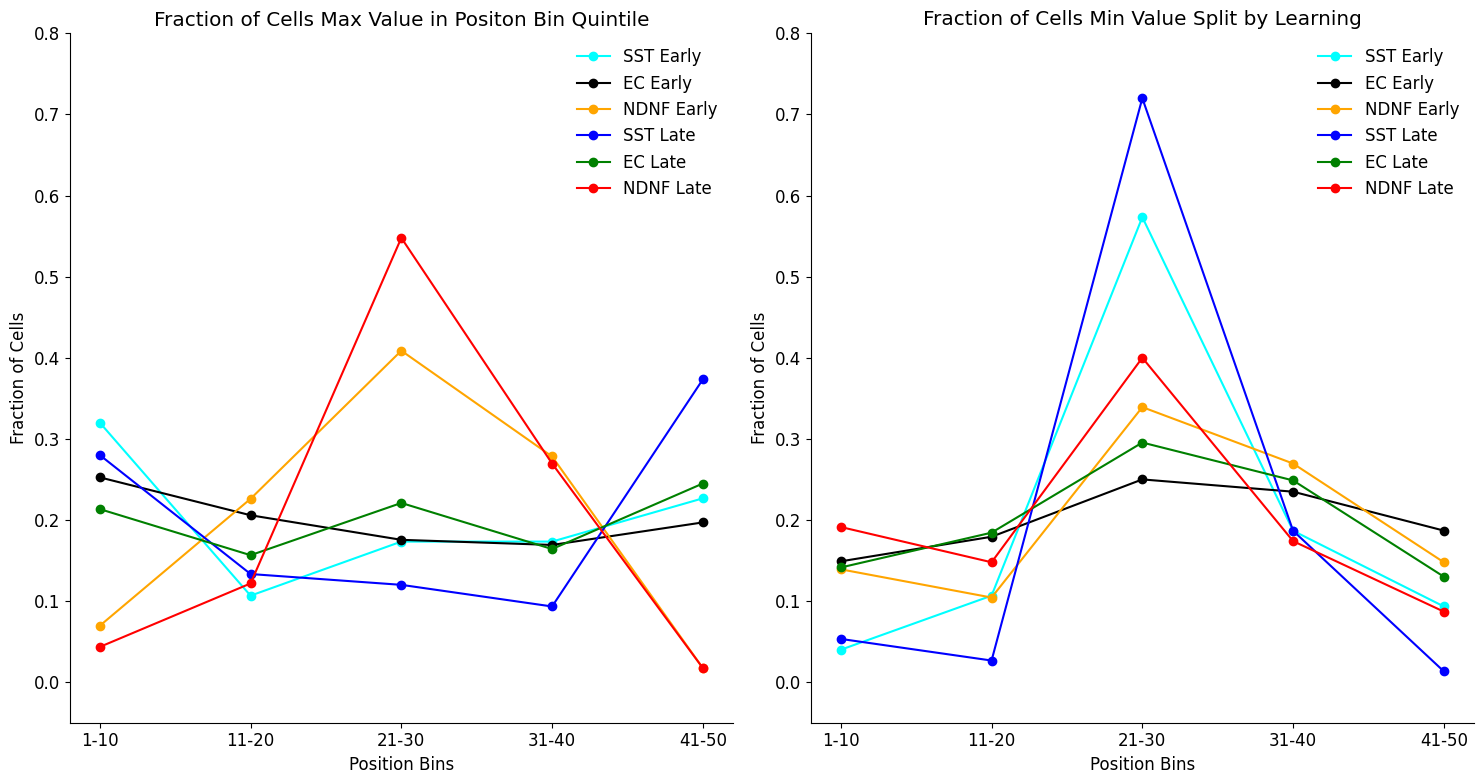

In [101]:


binned_data_SST_argmax_e = get_argmin_argmax_data_binned(activity_dict_SST, cp_dict_SST, use_argmax=True, split_early_late=True, use_early=True)
binned_data_SST_argmin_e = get_argmin_argmax_data_binned(activity_dict_SST, cp_dict_SST, use_argmax=False, split_early_late=True, use_early=True)

binned_data_SST_argmax_l = get_argmin_argmax_data_binned(activity_dict_SST, cp_dict_SST, use_argmax=True, split_early_late=True, use_early=False)
binned_data_SST_argmin_l = get_argmin_argmax_data_binned(activity_dict_SST, cp_dict_SST, use_argmax=False, split_early_late=True, use_early=False)

binned_data_EC_argmax_e = get_argmin_argmax_data_binned(activity_dict_EC, cp_dict_EC, use_argmax=True, split_early_late=True, use_early=True)
binned_data_EC_argmin_e = get_argmin_argmax_data_binned(activity_dict_EC, cp_dict_EC, use_argmax=False, split_early_late=True, use_early=True)

binned_data_EC_argmax_l = get_argmin_argmax_data_binned(activity_dict_EC, cp_dict_EC, use_argmax=True, split_early_late=True, use_early=False)
binned_data_EC_argmin_l = get_argmin_argmax_data_binned(activity_dict_EC, cp_dict_EC, use_argmax=False, split_early_late=True, use_early=False)

binned_data_NDNF_argmax_e = get_argmin_argmax_data_binned(fixed_residual_activity_dict_NDNF_newest, cp_dict_NDNF, use_argmax=True, split_early_late=True, use_early=True)
binned_data_NDNF_argmin_e = get_argmin_argmax_data_binned(fixed_residual_activity_dict_NDNF_newest, cp_dict_NDNF, use_argmax=False, split_early_late=True, use_early=True)

binned_data_NDNF_argmax_l = get_argmin_argmax_data_binned(fixed_residual_activity_dict_NDNF_newest, cp_dict_NDNF, use_argmax=True, split_early_late=True, use_early=False)
binned_data_NDNF_argmin_l = get_argmin_argmax_data_binned(fixed_residual_activity_dict_NDNF_newest, cp_dict_NDNF, use_argmax=False, split_early_late=True, use_early=False)


fig, axs = plt.subplots(1,2, figsize=(15,8))
axs[0].plot(binned_data_SST_argmax_e, color='cyan', label="SST Early", marker="o")
axs[0].plot(binned_data_EC_argmax_e, color='k', label="EC Early", marker="o")
axs[0].plot(binned_data_NDNF_argmax_e, color='orange', label="NDNF Early", marker="o")

axs[0].plot(binned_data_SST_argmax_l, color='b', label="SST Late", marker="o")
axs[0].plot(binned_data_EC_argmax_l, color='green', label="EC Late", marker="o")
axs[0].plot(binned_data_NDNF_argmax_l, color='red', label="NDNF Late", marker="o")

axs[0].set_ylabel("Fraction of Cells")
axs[0].set_xlabel("Position Bins")
axs[0].set_xticks(np.arange(5), ["1-10","11-20","21-30","31-40","41-50"])
axs[0].set_title("Fraction of Cells Max Value in Positon Bin Quintile")
axs[0].set_ylim(-0.05,0.8)
axs[0].legend()

axs[1].plot(binned_data_SST_argmin_e, color='cyan', label="SST Early", marker="o")
axs[1].plot(binned_data_EC_argmin_e, color='k', label="EC Early", marker="o")
axs[1].plot(binned_data_NDNF_argmin_e, color='orange', label="NDNF Early", marker="o")

axs[1].plot(binned_data_SST_argmin_l, color='b', label="SST Late", marker="o")
axs[1].plot(binned_data_EC_argmin_l, color='green', label="EC Late", marker="o")
axs[1].plot(binned_data_NDNF_argmin_l, color='red', label="NDNF Late", marker="o")

axs[1].set_ylabel("Fraction of Cells")
axs[1].set_xlabel("Position Bins")
axs[1].set_xticks(np.arange(5), ["1-10","11-20","21-30","31-40","41-50"])
axs[1].set_title("Fraction of Cells Min Value Split by Learning")
axs[1].set_ylim(-0.05,0.8)
axs[1].legend()

plt.tight_layout()
plt.show()


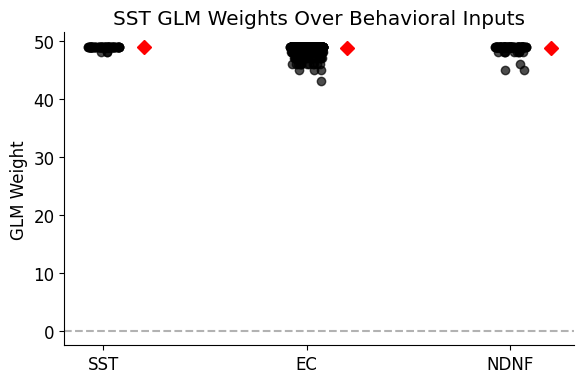

In [49]:
def get_cell_range_list(residual_activity_dict_EC):
    cell_range_list = []
    for animal in residual_activity_dict_EC:
        for cell in residual_activity_dict_EC[animal]:
            trial_peak_list = []
            data = residual_activity_dict_EC[animal][cell]
            for trial in range(data.shape[1]):
                trial_peak = np.argmax(data[:, trial])
                trial_peak_list.append(trial_peak)
            cell_range = np.max(trial_peak_list) - np.min(trial_peak_list)
            cell_range_list.append(cell_range)

    return cell_range_list

cell_range_list_SST = get_cell_range_list(residual_activity_dict_SST)
cell_range_list_EC = get_cell_range_list(residual_activity_dict_EC)
cell_range_list_NDNF = get_cell_range_list(fixed_residual_activity_dict_NDNF_newest)

# X positions and labels
x_labels = ['SST', 'EC', 'NDNF']
x_pos = np.arange(len(x_labels))  # [0, 1, 2]
x_offset = 0.2  # Offset for mean+SEM
jitter_strength = 0.08

# Create figure
plt.figure(figsize=(6, 4))

# Plot black dots with jitter
np.random.seed(0)  # for reproducibility
for i, weights in enumerate([cell_range_list_SST, cell_range_list_EC, cell_range_list_NDNF]):
    jitter = np.random.uniform(-jitter_strength, jitter_strength, size=len(weights))
    plt.scatter(np.full_like(weights, x_pos[i]) + jitter, weights, color='black', alpha=0.7)

# Plot diamond + SEM
for i, weights in enumerate([cell_range_list_SST, cell_range_list_EC, cell_range_list_NDNF]):
    mean_val = np.mean(weights)
    sem_val = sem(weights)
    plt.errorbar(x_pos[i] + x_offset, mean_val, yerr=sem_val,
                 fmt='D', color='red', capsize=4, markersize=7, label='_nolegend_')

# Formatting
plt.xticks(x_pos, x_labels)
plt.ylabel("GLM Weight")
plt.title("SST GLM Weights Over Behavioral Inputs")
plt.axhline(0, color='grey', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [ ]:
# from sklearn.model_selection import cross_val_score
# from sklearn.linear_model import LogisticRegression

# def fit_log_reg(neural_activity_sup_bef_V1, y, n_splits=10):
#   activity_list = []
#   for i in range(neural_activity_sup_bef_V1.shape[0]):
#     flat_activity = neural_activity_sup_bef_V1[i,:,:].flatten()
#     activity_list.append(flat_activity)

#   X = np.array(activity_list).T
#   # X = X[:,:100]

#   X_scaled = (X - np.min(X)) / (np.max(X) - np.min(X))

#   y_flat = y.flatten()

#   log_reg = LogisticRegression(penalty=None, max_iter=1000)

#   accuracies = cross_val_score(log_reg, X_scaled, y_flat, cv=n_splits)

#   return accuracies
# accuracies = fit_log_reg(neural_activity_sup_bef_V1, lick_data_array_before_sup, n_splits=10)
# accuracies = fit_log_reg(NDNF_activity_array, lick_data_array_before_sup, n_splits=10)
# print(accuracies)






# from sklearn.model_selection import cross_val_score
# from sklearn.linear_model import LogisticRegression

# def fit_log_reg(neural_activity_sup_bef_V1, y, n_splits=10):
#   activity_list = []
#   for i in range(neural_activity_sup_bef_V1.shape[0]):
#     flat_activity = neural_activity_sup_bef_V1[i,:,:].flatten()
#     activity_list.append(flat_activity)

#   X = np.array(activity_list).T
#   # X = X[:,:100]

#   y_flat = y.flatten()

#   log_reg = LogisticRegression(penalty=None, max_iter=1000)

#   accuracies = cross_val_score(log_reg, X, y_flat, cv=n_splits)
#   return accuracies





In [92]:

def get_mean_accuracy_dict(NDNF_dict, log_reg_animal_dict):
    mean_accuracy_list_NDNF_lick = []
    for animal in NDNF_dict:
        animal_accuracy = log_reg_animal_dict[animal]["accuracies"]
        mean_animal_accuracy = np.mean(animal_accuracy) *100
        mean_accuracy_list_NDNF_lick.append(mean_animal_accuracy)

    return mean_accuracy_list_NDNF_lick

mean_accuracy_list_NDNF_lick = get_mean_accuracy_dict(NDNF_dict, log_reg_animal_dict_NDNF_lick)
mean_accuracy_list_NDNF_lick_res = get_mean_accuracy_dict(NDNF_residual_dict, log_reg_animal_dict_NDNF_lick_res)

mean_accuracy_list_EC_lick = get_mean_accuracy_dict(EC_dict, log_reg_animal_dict_EC_lick)
mean_accuracy_list_EC_lick_res = get_mean_accuracy_dict(EC_residual_dict, log_reg_animal_dict_EC_lick_res)

mean_accuracy_list_SST_lick = get_mean_accuracy_dict(SST_dict, log_reg_animal_dict_SST_lick)
mean_accuracy_list_SST_lick_res = get_mean_accuracy_dict(SST_residual_dict, log_reg_animal_dict_SST_lick_res)


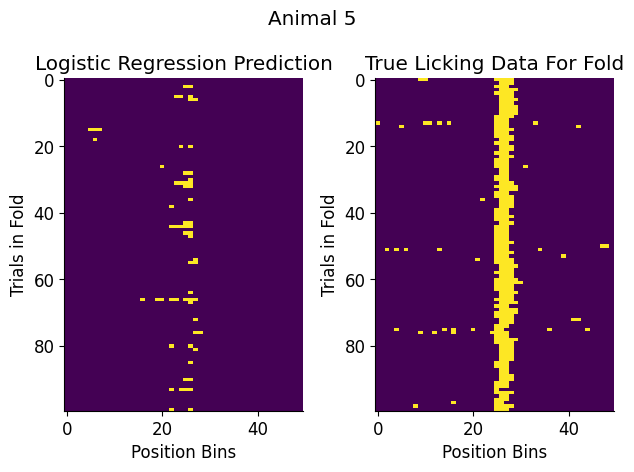

In [106]:
animal = 5
fig, axs = plt.subplots(1,2)
plt.suptitle(f"Animal {animal}")
axs[0].imshow(log_reg_animal_dict_NDNF_lick[animal]["all_preds_reshaped"].T, aspect='auto')
axs[1].imshow(log_reg_animal_dict_NDNF_lick[animal]["y_true_reshaped"].T, aspect='auto')
axs[0].set_title("Logistic Regression Prediction")
axs[1].set_title("True Licking Data For Fold")
axs[0].set_xlabel("Position Bins")
axs[0].set_ylabel("Trials in Fold")
axs[1].set_xlabel("Position Bins")
axs[1].set_ylabel("Trials in Fold")

plt.tight_layout()
plt.show()

/var/folders/hl/zfn0lkv15xx80f47pqqz8p9c0000gn/T/ipykernel_766/2711541857.py:25: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:red'` for the same effect.

  sns.pointplot(x='Group', y='Accuracy', hue='Group', data=df, color='red', errorbar='sd', markers='d', err_kws={'linewidth': 1.5})


ANOVA: F = 17.28, p = 0.0000
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
    EC   NDNF   16.817 0.0002  8.1289 25.5051   True
    EC    SST  20.7596    0.0 11.6268 29.8924   True
  NDNF    SST   3.9426 0.4327 -3.8525 11.7377  False
----------------------------------------------------


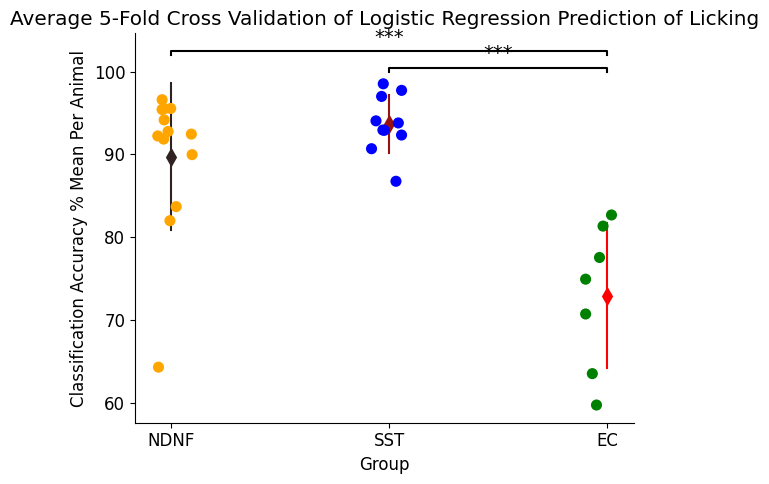

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import pandas as pd

# --- Your data ---
ndnf = mean_accuracy_list_NDNF_lick
sst = mean_accuracy_list_SST_lick
ec = mean_accuracy_list_EC_lick

# ndnf_res = mean_accuracy_list_NDNF_lick_res
# sst_res = mean_accuracy_list_SST_lick
# ec_res = mean_accuracy_list_EC_lick

# Combine into a DataFrame
data = ndnf + sst + ec
groups = (['NDNF'] * len(ndnf)) + (['SST'] * len(sst)) + (['EC'] * len(ec))
df = pd.DataFrame({'Group': groups, 'Accuracy': data})

# --- Plot ---
plt.figure(figsize=(6, 5))
sns.stripplot(x='Group', y='Accuracy', hue='Group', data=df, jitter=True, size=8, palette={'NDNF':'orange', 'SST':'blue', 'EC':'green'})
sns.pointplot(x='Group', y='Accuracy', hue='Group', data=df, color='red', errorbar='sd', markers='d', err_kws={'linewidth': 1.5})

plt.ylabel("Classification Accuracy % Mean Per Animal")
plt.title("Average 5-Fold Cross Validation of Logistic Regression Prediction of Licking")

# --- ANOVA ---
f_val, p_val = f_oneway(ndnf, sst, ec)
print(f"ANOVA: F = {f_val:.2f}, p = {p_val:.4f}")

# --- Tukey HSD post-hoc ---
tukey = pairwise_tukeyhsd(endog=df['Accuracy'], groups=df['Group'], alpha=0.05)
print(tukey)

# --- Add significance stars manually ---
# Get means per group for y positions
means = df.groupby('Group')['Accuracy'].mean().to_dict()
y_offset = 2

# Helper function to add stars
def add_star(x1, x2, y, star, y_offset = 0.5):
    plt.plot([x1, x1, x2, x2], [y, y+y_offset, y+y_offset, y], lw=1.5, color='black')
    plt.text((x1 + x2) / 2, y + y_offset + 0.5, star, ha='center', va='bottom', fontsize=14)

# Get Tukey HSD results table as a DataFrame
tukey_df = pd.DataFrame(data=tukey._results_table.data[1:], columns=tukey._results_table.data[0])


custom_y_locs = {
    ('NDNF', 'SST'): 85,
    ('NDNF', 'EC'): 102,
    ('SST', 'EC'): 100
}

# Format the group names for matching
pairs = [('NDNF', 'SST'), ('NDNF', 'EC'), ('SST', 'EC')]
for group1, group2 in pairs:
    row = tukey_df[((tukey_df['group1'] == group1) & (tukey_df['group2'] == group2)) |
                   ((tukey_df['group1'] == group2) & (tukey_df['group2'] == group1))]

    if row.empty:
        continue  # Skip if no match

    p = float(row['p-adj'].values[0])
    if p < 0.001:
        stars = '***'
    elif p < 0.01:
        stars = '**'
    elif p < 0.05:
        stars = '*'
    else:
        stars = 'n.s.'

    if stars != 'n.s.':
        x1, x2 = ['NDNF', 'SST', 'EC'].index(group1), ['NDNF', 'SST', 'EC'].index(group2)
        # y = max(means[group1], means[group2]) + 3
        y = custom_y_locs.get((group1, group2), 85)
        add_star(x1, x2, y, stars)

plt.tight_layout()
plt.show()


In [1]:
def get_model_dict(EC_data_array, fixed_residual_activity_dict_NDNF_newest, min_val, reg_type="ridge"):
    model_EC = {}
    for animal in fixed_residual_activity_dict_NDNF_newest:
        cell_model_EC = {}
        for cell in fixed_residual_activity_dict_NDNF_newest[animal]:
            neuron_activity = fixed_residual_activity_dict_NDNF_newest[animal][cell][:,:min_val]
            neuron_activity_flat = neuron_activity.flatten()
            model_NDNF = fit_GLM2(EC_data_array, neuron_activity_flat, regression=reg_type, alphas=None)
            cell_model_EC[cell] = model_NDNF
        model_EC[animal] = cell_model_EC
        
    return model_EC


model_EC_dict_early = get_model_dict(early_EC_array, activity_dict_EC, min_val_EC_early, reg_type="ridge")


NameError: name 'early_EC_array' is not defined

In [ ]:

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Step 1: Create DataFrame
df = pd.DataFrame({
    "MSE": (
        MSE_list_just_SST +
        MSE_list_just_EC +strip
        MSE_list_just_CA3 +
        MSE_list_EC_CA3 +
        MSE_list_EC_SST +
        MSE_list_CA3_SST +
        MSE_list_EC_CA3_SST
    ),
    "Input": (
        ["SST"] * len(MSE_list_just_SST) +
        ["EC"] * len(MSE_list_just_EC) +
        ["CA3"] * len(MSE_list_just_CA3) +
        ["EC + CA3"] * len(MSE_list_EC_CA3) +
        ["EC + SST"] * len(MSE_list_EC_SST) +
        ["CA3 + SST"] * len(MSE_list_CA3_SST) +
        ["EC + CA3 + SST"] * len(MSE_list_EC_CA3_SST)
    )
})

# Step 2: Define custom color palette
custom_palette = {
    "SST": "blue",
    "EC": "green",
    "CA3": "red",
    "EC + CA3": "yellow",
    "EC + SST": "cyan",
    "CA3 + SST": "purple",
    "EC + CA3 + SST": "orange"
}

# Step 3: Plot
plt.figure(figsize=(10, 6))
sns.violinplot(x="Input", y="MSE", data=df, inner="box", cut=0, palette=custom_palette)
plt.title("NDNF Cell MSE by Input Cell Type")
plt.ylabel("Mean Squared Error")
plt.xlabel("Input Type")
plt.xticks(rotation=20)
plt.ylim(0,1.75)
plt.tight_layout()
plt.show()

In [ ]:
min_trials = 1000
for animal in activity_dict_SST:
    for cell in activity_dict_SST[animal]:
        if activity_dict_SST[animal][cell].shape[1] < min_trials:
            min_trials = activity_dict_SST[animal][cell].shape[1]

print(min_trials)

63


(75, 50, 20)

In [ ]:
heres neuron over all trial give me latent factors but enforce predefined latent factor --- hand in a latent that is lick 

do no binned for lick, velocity, position-- unfiltered licks -- try to fit glm on that 

In [2]:
###### correct hit ###### all the corrrect licks excluded 




###### getting behavioral weights over NDNF 


def fit_GLM2(EC_data_array, neuron_activity_flat, regression='linear', alphas=None):
    
    design_matrix_X = EC_data_array.T
    
    if regression == 'linear':
        model = LinearRegression()
    elif regression == 'lasso':
        model = LassoCV(alphas=alphas, cv=None) if alphas is not None else LassoCV(cv=None)
    elif regression == 'ridge':
        model = RidgeCV(alphas=alphas if alphas is not None else [0.1, 1, 10, 100, 1000, 5000], cv=None)
    elif regression == 'elastic':
        l1_ratio = [0.1, 0.3, 0.5, 0.7, 0.9, 1]
        model = ElasticNetCV(alphas=alphas if alphas is not None else [0.1, 1, 10, 100, 1000, 5000],
                             l1_ratio=l1_ratio, cv=None)

    model.fit(design_matrix_X, neuron_activity_flat)
    # neuron_predicted_activity = model.predict(design_matrix_X)
    
    return model 




NameError: name 'remove_behaviors_GLM' is not defined

In [3]:
def get_prediction_lists(prediction_list_EC, prediction_list_EC_minusL, prediction_list_EC_minusR, prediction_list_EC_minusV):
    prediction_overall_list = []
    prediction_minusL_list = []
    prediction_minusR_list = []
    prediction_minusV_list = []

    for i in range(len(prediction_list_EC)):
        prediction_overall_list.append(np.mean(prediction_list_EC[i], axis=1))
        prediction_minusL_list.append(np.mean(prediction_list_EC_minusL[i], axis=1))
        prediction_minusR_list.append(np.mean(prediction_list_EC_minusR[i], axis=1))
        prediction_minusV_list.append(np.mean(prediction_list_EC_minusV[i], axis=1))

    return prediction_overall_list, prediction_minusL_list, prediction_minusR_list, prediction_minusV_list

prediction_overall_list_EC, prediction_minusL_list_EC, prediction_minusR_list_EC, prediction_minusV_list_EC = get_prediction_lists(prediction_list_EC, prediction_list_EC_minusL, prediction_list_EC_minusR, prediction_list_EC_minusV)
prediction_overall_list_NDNF, prediction_minusL_list_NDNF, prediction_minusR_list_NDNF, prediction_minusV_list_NDNF = get_prediction_lists(prediction_list_NDNF, prediction_list_NDNF_minusL, prediction_list_NDNF_minusR, prediction_list_NDNF_minusV)
prediction_overall_list_SST, prediction_minusL_list_SST, prediction_minusR_list_SST, prediction_minusV_list_SST = get_prediction_lists(prediction_list_SST, prediction_list_SST_minusL, prediction_list_SST_minusR, prediction_list_SST_minusV)







def plotting_helper(prediction_overall_list, ax, color="k", label="All Coeff. Included", linestyle="--"):
    prediction_overall_array = np.array(prediction_overall_list)

    mean_overall = np.mean(prediction_overall_array, axis=0)
    sem_overall = sem(prediction_overall_array, axis=0)

    ax.plot(mean_overall, color=color, label=label, linestyle=linestyle)
    ax.fill_between(range(len(mean_overall)), mean_overall - sem_overall, mean_overall + sem_overall,
                    alpha=0.2, color=color)


fig, axs = plt.subplots(3, 2, figsize=(15, 15))
ax = axs[0, 0] 
plotting_helper(prediction_overall_list_EC, ax=ax, color='k', label="All Coeff. Included", linestyle='-')
plotting_helper(prediction_minusL_list_EC, ax=ax, color='g', label="Minus L", linestyle='--')
plotting_helper(prediction_minusR_list_EC, ax=ax, color='r', label="Minus R", linestyle='--')
plotting_helper(prediction_minusV_list_EC, ax=ax, color='b', label="Minus V", linestyle='--')
ax.legend()

ax = axs[1, 0] 
plotting_helper(prediction_overall_list_SST, ax=ax, color='k', label="All Coeff. Included", linestyle='-')
plotting_helper(prediction_minusL_list_SST, ax=ax, color='g', label="Minus L", linestyle='--')
plotting_helper(prediction_minusR_list_SST, ax=ax, color='r', label="Minus R", linestyle='--')
plotting_helper(prediction_minusV_list_SST, ax=ax, color='b', label="Minus V", linestyle='--')
ax.legend()

ax = axs[2, 0] 
plotting_helper(prediction_overall_list_NDNF, ax=ax, color='k', label="All Coeff. Included", linestyle='-')
plotting_helper(prediction_minusL_list_NDNF, ax=ax, color='g', label="Minus L", linestyle='--')
plotting_helper(prediction_minusR_list_NDNF, ax=ax, color='r', label="Minus R", linestyle='--')
plotting_helper(prediction_minusV_list_NDNF, ax=ax, color='b', label="Minus V", linestyle='--')


ax.legend()
plt.tight_layout()

plt.legend()
plt.tight_layout()
plt.show()


NameError: name 'prediction_list_EC' is not defined

In [ ]:

def get_activitys(activity_dict_SST):
    SST_data_list = []
    for animal in activity_dict_SST:
        for cell in activity_dict_SST[animal]:
            # SST_data_list.append(np.mean(activity_dict_SST[animal][cell][:,:end], axis=1))
            SST_data_list.append(np.mean(activity_dict_SST[animal][cell], axis=1))

    SST_data_array_early = np.array(SST_data_list)
    return SST_data_array_early

SST_datas = get_activitys(activity_dict_SST)
EC_datas = get_activitys(activity_dict_EC)
NDNF_datas = get_activitys(fixed_activity_dict_NDNF_newest)

SST_datas_r = get_activitys(residual_activity_dict_SST)
EC_datas_r = get_activitys(residual_activity_dict_EC)
NDNF_datas_r = get_activitys(fixed_residual_activity_dict_NDNF_newest)



In [ ]:

lick_weights = []
reward_weights = []
velocity_weights = []

for i in weights_list_EC:
    lick_weights.append(i[0])
    reward_weights.append(i[1])
    velocity_weights.append(i[2])

input_data = [lick_weights, reward_weights, velocity_weights]
input_keys = ['Lick', 'Reward', 'Velocity']

def plot_coefficients_cell_type(input_data, input_keys, cell_type="EC"):
    

    df = pd.DataFrame({
        'Lick': lick_weights,
        'Reward': reward_weights,
        'Velocity': velocity_weights
    })

    # Melt for long-form plotting
    df_melted = df.melt(var_name='Variable', value_name='Weight')

    # Plot
    plt.figure(figsize=(6, 5))
    # sns.pointplot(data=df_melted, x='Variable', y='Weight', color='red', join=False, errorbar='sd', markers='d', err_kws={'linewidth': 1.5})
    sns.stripplot(data=df_melted, x='Variable', y='Weight', color='black', jitter=True, alpha=0.5)

    offset=0.2

    variable_names = ['Lick', 'Reward', 'Velocity']
    for i, var in enumerate(variable_names):
        values = df[var]
        mean = np.mean(values)
        se = np.std(values) / np.sqrt(len(values))
        plt.errorbar(i + offset, mean, yerr=se, fmt='d', color='red',
                     capsize=5, elinewidth=1.5, markeredgewidth=1.5)

    plt.axhline(0, linestyle='--', color='grey')
    plt.title(f'GLM Coefficients {cell_type}')
    plt.ylabel('Weight')
    plt.tight_layout()
    plt.show()

plot_coefficients_cell_type(weights_list_EC, cell_type="EC")
plot_coefficients_cell_type(weights_list_NDNF, cell_type="NDNF")
plot_coefficients_cell_type(weights_list_SST, cell_type="SST")


792

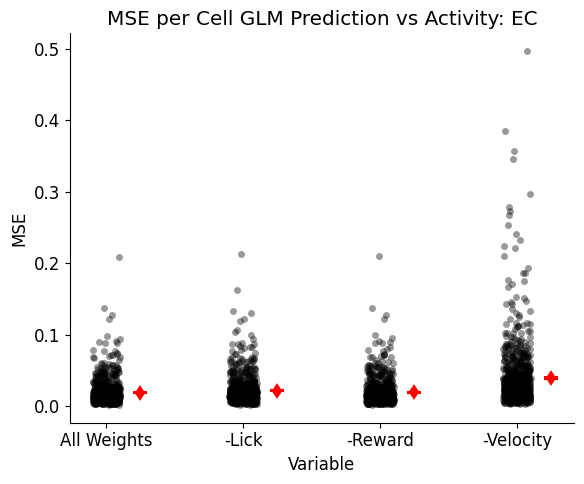

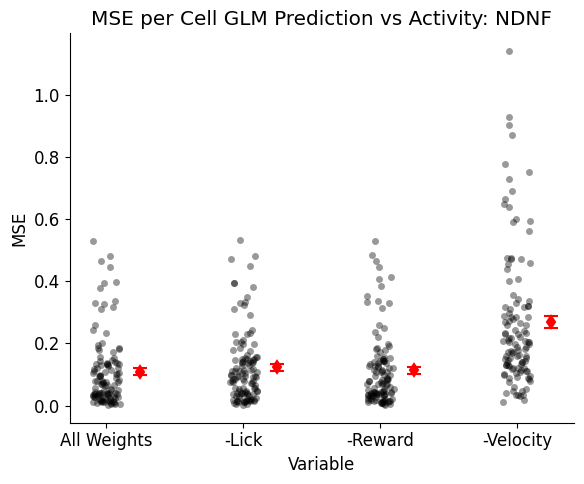

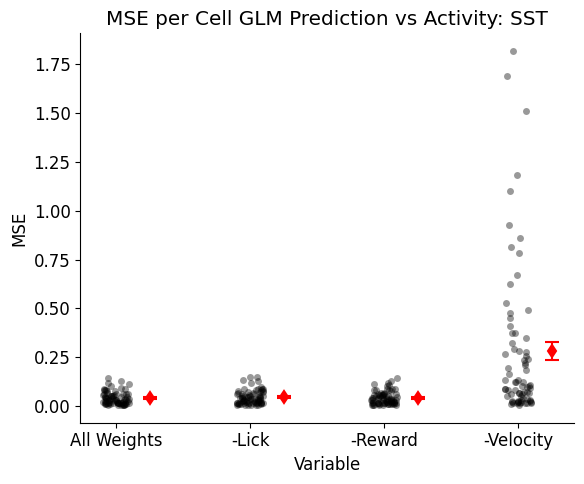

In [ ]:

def plot_coefficients_modular(input_data, input_keys, ax=axs[0,0], cell_type="Cell Type", title_prefix="GLM Coefficients", ylabel="MSE"):
    """
    Plots stripplot + mean ± SEM for input variables.

    Parameters:
    - input_data: list of arrays/lists, one per variable
    - input_keys: list of strings, labels for each variable
    - cell_type: string to appear in the plot title
    - title_prefix: string for title prefix
    """
    assert len(input_data) == len(input_keys), "input_data and input_keys must have same length"
    
    # Combine into a dictionary and then DataFrame
    data_dict = {key: values for key, values in zip(input_keys, input_data)}
    df = pd.DataFrame(data_dict)
    
    # Melt for long-form plotting
    df_melted = df.melt(var_name='Variable', value_name='Weight')
    
    # Plot
    plt.figure(figsize=(max(6, len(input_keys)*1.5), 5))
    sns.stripplot(data=df_melted, x='Variable', y='Weight', color='black', jitter=True, alpha=0.4)

    offset = 0.25
    for i, key in enumerate(input_keys):
        values = df[key]
        mean = np.mean(values)
        se = np.std(values) / np.sqrt(len(values))
        plt.errorbar(i + offset, mean, yerr=se, fmt='d', color='red',
                     capsize=5, elinewidth=1.5, markeredgewidth=1.5)
    
    ax.set_title(f'{title_prefix}: {cell_type}')
    ax.set_ylabel(ylabel)


# input_data = [MSE_list_EC, MSE_list_EC_minusL, MSE_list_EC_minusR, MSE_list_EC_minusV]
# input_keys = ["All Weights", "-Lick", "-Reward", "-Velocity"]
# plot_coefficients_modular(input_data, input_keys, cell_type="EC", title_prefix="MSE per Cell GLM Prediction vs Activity", ylabel="MSE")

# input_data = [MSE_list_NDNF, MSE_list_NDNF_minusL, MSE_list_NDNF_minusR, MSE_list_NDNF_minusV]
# input_keys = ["All Weights", "-Lick", "-Reward", "-Velocity"]
# plot_coefficients_modular(input_data, input_keys, cell_type="NDNF", title_prefix="MSE per Cell GLM Prediction vs Activity", ylabel="MSE")

# input_data = [MSE_list_SST, MSE_list_SST_minusL, MSE_list_SST_minusR, MSE_list_SST_minusV]
# input_keys = ["All Weights", "-Lick", "-Reward", "-Velocity"]
# plot_coefficients_modular(input_data, input_keys, cell_type="SST", title_prefix="MSE per Cell GLM Prediction vs Activity", ylabel="MSE")




In [ ]:


input_data = [MSE_list_EC, MSE_list_EC_minusL, MSE_list_EC_minusR, MSE_list_EC_minusV]
input_keys = ["All Weights", "-Lick", "-Reward", "-Velocity"]
plot_coefficients_modular(input_data, input_keys, cell_type="EC", title_prefix="MSE per Cell GLM Prediction vs Activity", ylabel="MSE")

input_data = [MSE_list_NDNF, MSE_list_NDNF_minusL, MSE_list_NDNF_minusR, MSE_list_NDNF_minusV]
input_keys = ["All Weights", "-Lick", "-Reward", "-Velocity"]
plot_coefficients_modular(input_data, input_keys, cell_type="NDNF", title_prefix="MSE per Cell GLM Prediction vs Activity", ylabel="MSE")

input_data = [MSE_list_SST, MSE_list_SST_minusL, MSE_list_SST_minusR, MSE_list_SST_minusV]
input_keys = ["All Weights", "-Lick", "-Reward", "-Velocity"]
plot_coefficients_modular(input_data, input_keys, cell_type="SST", title_prefix="MSE per Cell GLM Prediction vs Activity", ylabel="MSE")

plt.tight_layout()
plt.show()


Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 5 cells
    Animal 1: 15 cells
    Animal 2: 6 cells
    Animal 3: 4 cells
    Animal 4: 13 cells
    Animal 5: 13 cells
    Animal 6: 3 cells
    Animal 7: 3 cells
    Animal 8: 3 cells
    Animal 9: 10 cells
Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 192 cells
    Animal 1: 150 cells
    Animal 2: 154 cells
    Animal 3: 82 cells
    Animal 4: 74 cells
    Animal 5: 64 cells
    Animal 6: 76 cells
Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 12 cells
    Animal 1: 16 cells
    Animal 2: 4 cells
    Animal 3: 10 cells
    Animal 4: 8 cells
    Animal 5: 7 cells
    Animal 6: 11 cells
    Animal 7: 10 cells
    Animal 8: 17 cells
    Animal 9: 17 cells
    Animal 10: 9 cells
    Animal 11: 6 cells
    Animal 12: 10 cells
    Animal 13: 9 cells
    Animal 14: 6 cells
    Animal 15: 12 cells
    Animal 16: 7 cells
    Animal 17: 7 cells
    Animal 18: 7 cells
    Animal 19: 10 cells
    Animal 20: 9 cells
    Animal 21: 

dict_keys(['Licks', 'Reward_loc', 'Velocity', 'Position_1', 'Position_2', 'Position_3', 'Position_4', 'Position_5', 'Position_6', 'Position_7', 'Position_8', 'Position_9', 'Position_10'])


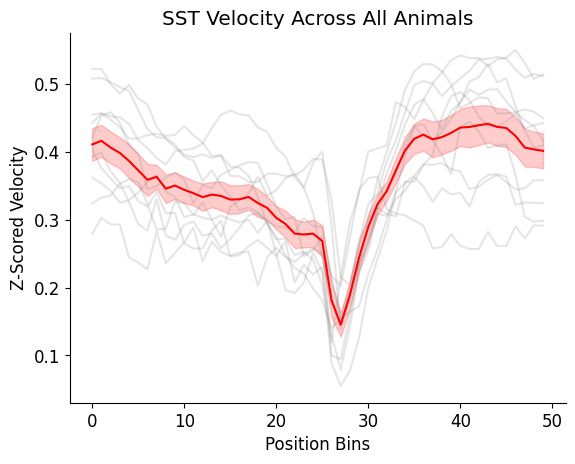

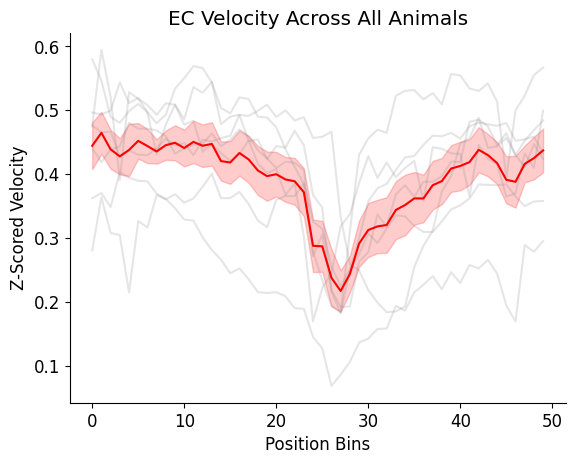

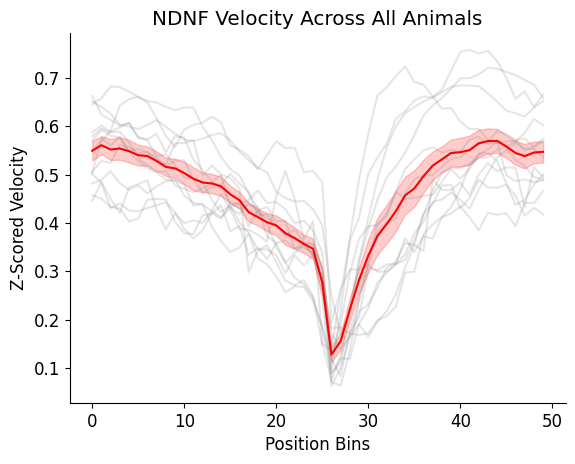

In [ ]:
###################### In case of Emergency this will plot all cells activities and velocities 

plot_data(SST_datas, SST_datas_r, title="SST Activity Across All Cells", color='b')
plot_data(EC_datas, EC_datas_r, title="EC Activity Across All Cells", color='green')
plot_data(NDNF_datas, NDNF_datas_r, title="NDNF Activity Across All Cells", color='orange')


SST_velocity_array = get_velocities(factors_dict_SST)
EC_velocity_array = get_velocities(factors_dict_EC)
NDNF_velocity_array = get_velocities(fixed_factors_dict_NDNF_newest)

plot_datar(SST_velocity_array, title="SST Velocity Across All Animals", color='r')
plot_datar(EC_velocity_array, title="EC Velocity Across All Animals", color='r')
plot_datar(NDNF_velocity_array, title="NDNF Velocity Across All Animals", color='r')